# Import the required libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sn
from sklearn import preprocessing
import missingno as mn
import sklearn
from sklearn.impute import KNNImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import pairwise_distances
from sklearn.metrics import silhouette_score
import joblib
import pickle
from scipy.stats import kendalltau

import seaborn as sns; sns.set()
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import validation_curve



# load LFB_dataset

In [ ]:
df = pd.read_excel(r'C:\\Users\\Student\\Downloads\\Asma zulqarnain\\Ask Lsbu\\January 2023-2nd Semester\\data mining and analysis\\coursework1\\LFB_ds.xlsx')
df

,IncidentNumber,DateOfCall,CalYear,TimeOfCall,HourOfCall,IncidentGroup,StopCodeDescription,SpecialServiceType,PropertyCategory,PropertyType,...,FirstPumpArriving_AttendanceTime,FirstPumpArriving_DeployedFromStation,SecondPumpArriving_AttendanceTime,SecondPumpArriving_DeployedFromStation,NumStationsWithPumpsAttending,NumPumpsAttending,PumpCount,PumpHoursRoundUp,Notional Cost (£),NumCalls
0,000006-01012019,01 Jan 2019,2019,00:01:45,0,Special Service,Special Service,Lift Release,Dwelling,Purpose Built Flats/Maisonettes - 4 to 9 storeys,...,NaN,NaN,NaN,NaN,1.0,1.0,1.0,1.0,333.0,2.0
1,000019-01012019,01 Jan 2019,2019,00:04:33,0,Fire,Secondary Fire,NaN,Outdoor,Tree scrub,...,357.0,Edmonton,NaN,NaN,1.0,1.0,1.0,1.0,333.0,1.0
2,000020-01012019,01 Jan 2019,2019,00:04:39,0,False Alarm,False alarm - Good intent,NaN,Outdoor,Domestic garden (vegetation not equipment),...,318.0,Southgate,NaN,NaN,1.0,1.0,1.0,1.0,333.0,1.0
3,000021-01012019,01 Jan 2019,2019,00:04:44,0,False Alarm,AFA,NaN,Dwelling,Stately Home (part not open to public),...,210.0,Kensington,NaN,NaN,1.0,1.0,1.0,1.0,333.0,1.0
4,000024-01012019,01 Jan 2019,2019,00:05:00,0,Special Service,Special Service,Lift Release,Dwelling,Purpose Built Flats/Maisonettes - 4 to 9 storeys,...,329.0,Bethnal Green,NaN,NaN,1.0,1.0,1.0,1.0,333.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
426456,195658-30112022,30 Nov 2022,2022,23:20:30,23,Special Service,Special Service,Hazardous Materials incident,Dwelling,House - single occupancy,...,327.0,Norbury,331.0,Norbury,1.0,2.0,2.0,1.0,364.0,1.0
426457,195660-30112022,30 Nov 2022,2022,23:29:08,23,False Alarm,False alarm - Good intent,NaN,Non Residential,Takeaway/ fast food,...,142.0,Islington,302.0,Shoreditch,2.0,2.0,2.0,1.0,364.0,1.0
426458,195662-30112022,30 Nov 2022,2022,23:35:14,23,False Alarm,AFA,NaN,Dwelling,Purpose Built Flats/Maisonettes - Up to 3 stor...,...,205.0,Acton,NaN,NaN,1.0,1.0,1.0,1.0,364.0,1.0
426459,195663-30112022,30 Nov 2022,2022,23:49:58,23,Special Service,Special Service,RTC,Road Vehicle,Multiple Vehicles,...,251.0,Erith,407.0,Bexley,2.0,2.0,2.0,2.0,728.0,2.0


# filtering dataset

In [ ]:
new_df = df[df['IncGeo_BoroughName'] == 'HILLINGDON']
new_df

,IncidentNumber,DateOfCall,CalYear,TimeOfCall,HourOfCall,IncidentGroup,StopCodeDescription,SpecialServiceType,PropertyCategory,PropertyType,...,FirstPumpArriving_AttendanceTime,FirstPumpArriving_DeployedFromStation,SecondPumpArriving_AttendanceTime,SecondPumpArriving_DeployedFromStation,NumStationsWithPumpsAttending,NumPumpsAttending,PumpCount,PumpHoursRoundUp,Notional Cost (£),NumCalls
60,000200-01012019,01 Jan 2019,2019,01:15:12,1,Fire,Primary Fire,NaN,Dwelling,House - single occupancy,...,357.0,Southall,529.0,Northolt,2.0,2.0,2.0,2.0,666.0,2.0
115,000344-01012019,01 Jan 2019,2019,05:51:14,5,False Alarm,AFA,NaN,Dwelling,Converted Flat/Maisonette - Up to 2 storeys,...,437.0,Harrow,442.0,Ruislip,2.0,2.0,2.0,1.0,333.0,1.0
148,000408-01012019,01 Jan 2019,2019,10:25:01,10,Special Service,Special Service,No action (not false alarm),Outdoor,Lake/pond/reservoir,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0
185,000465-01012019,01 Jan 2019,2019,14:14:03,14,False Alarm,AFA,NaN,Non Residential,Airport - terminal,...,575.0,Hayes,364.0,Feltham,2.0,3.0,3.0,1.0,333.0,1.0
203,000496-01012019,01 Jan 2019,2019,15:50:35,15,Fire,Primary Fire,NaN,Dwelling,Converted Flat/Maisonette - Up to 2 storeys,...,364.0,Hillingdon,370.0,Hillingdon,1.0,2.0,2.0,1.0,333.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
426263,195344-30112022,30 Nov 2022,2022,11:37:36,11,False Alarm,AFA,NaN,Non Residential,Train station - platform (below ground),...,216.0,Heathrow,NaN,NaN,1.0,1.0,1.0,1.0,364.0,1.0
426307,195407-30112022,30 Nov 2022,2022,13:44:05,13,Fire,Primary Fire,NaN,Dwelling,House - single occupancy,...,360.0,Hillingdon,361.0,Hillingdon,1.0,2.0,2.0,1.0,364.0,1.0
426321,195427-30112022,30 Nov 2022,2022,14:35:45,14,False Alarm,False alarm - Good intent,NaN,Outdoor,Domestic garden (vegetation not equipment),...,828.0,Hillingdon,NaN,NaN,1.0,1.0,1.0,1.0,364.0,1.0
426325,195433-30112022,30 Nov 2022,2022,14:53:53,14,False Alarm,AFA,NaN,Dwelling,Self contained Sheltered Housing,...,735.0,Northolt,NaN,NaN,1.0,1.0,1.0,1.0,364.0,2.0


In [ ]:
pwd

'C:\\Users\\Student\\Downloads\\Asma zulqarnain\\Ask Lsbu\\January 2023-2nd Semester\\data mining and analysis\\coursework1'

In [ ]:
print(f'the number of rows in data {new_df.shape[0]}')
print(f'the number of features in data {new_df.shape[1]}')
#df.shape # number of rows, number of columns

the number of rows in data 13267
the number of features in data 39


In [ ]:
df.shape
new_df.shape
f'new_df is {round((len(new_df)/len(df)), 4)*100}% of df'

'new_df is 3.11% of df'

# Exploratory data analysis (EDA)

In [ ]:
new_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 13267 entries, 60 to 426415
Data columns (total 39 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   IncidentNumber                          13267 non-null  object 
 1   DateOfCall                              13267 non-null  object 
 2   CalYear                                 13267 non-null  int64  
 3   TimeOfCall                              13267 non-null  object 
 4   HourOfCall                              13267 non-null  int64  
 5   IncidentGroup                           13267 non-null  object 
 6   StopCodeDescription                     13267 non-null  object 
 7   SpecialServiceType                      3737 non-null   object 
 8   PropertyCategory                        13267 non-null  object 
 9   PropertyType                            13267 non-null  object 
 10  AddressQualifier                        13267 non-null  

In [ ]:
new_df.head()

,IncidentNumber,DateOfCall,CalYear,TimeOfCall,HourOfCall,IncidentGroup,StopCodeDescription,SpecialServiceType,PropertyCategory,PropertyType,...,FirstPumpArriving_AttendanceTime,FirstPumpArriving_DeployedFromStation,SecondPumpArriving_AttendanceTime,SecondPumpArriving_DeployedFromStation,NumStationsWithPumpsAttending,NumPumpsAttending,PumpCount,PumpHoursRoundUp,Notional Cost (£),NumCalls
60,000200-01012019,01 Jan 2019,2019,01:15:12,1,Fire,Primary Fire,NaN,Dwelling,House - single occupancy,...,357.0,Southall,529.0,Northolt,2.0,2.0,2.0,2.0,666.0,2.0
115,000344-01012019,01 Jan 2019,2019,05:51:14,5,False Alarm,AFA,NaN,Dwelling,Converted Flat/Maisonette - Up to 2 storeys,...,437.0,Harrow,442.0,Ruislip,2.0,2.0,2.0,1.0,333.0,1.0
148,000408-01012019,01 Jan 2019,2019,10:25:01,10,Special Service,Special Service,No action (not false alarm),Outdoor,Lake/pond/reservoir,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0
185,000465-01012019,01 Jan 2019,2019,14:14:03,14,False Alarm,AFA,NaN,Non Residential,Airport - terminal,...,575.0,Hayes,364.0,Feltham,2.0,3.0,3.0,1.0,333.0,1.0
203,000496-01012019,01 Jan 2019,2019,15:50:35,15,Fire,Primary Fire,NaN,Dwelling,Converted Flat/Maisonette - Up to 2 storeys,...,364.0,Hillingdon,370.0,Hillingdon,1.0,2.0,2.0,1.0,333.0,2.0


In [ ]:
new_df.describe()

,CalYear,HourOfCall,UPRN,USRN,Easting_m,Northing_m,Easting_rounded,Northing_rounded,Latitude,Longitude,FirstPumpArriving_AttendanceTime,SecondPumpArriving_AttendanceTime,NumStationsWithPumpsAttending,NumPumpsAttending,PumpCount,PumpHoursRoundUp,Notional Cost (£),NumCalls
count,13267.000000,13267.000000,1.326700e+04,1.326700e+04,8166.000000,8166.000000,13267.000000,13267.000000,8166.000000,8166.000000,12803.000000,4833.000000,13153.000000,13153.000000,13166.000000,13162.000000,13162.000000,13267.00000
mean,2020.533127,13.407251,3.220999e+10,2.217676e+07,507963.109846,181373.302964,508161.803724,182181.212784,50.978882,-0.440373,371.248770,475.244982,1.373983,1.506881,1.573902,1.456010,508.887631,1.40710
std,1.137541,6.209801,4.651034e+10,7.770994e+06,2072.781153,4600.208290,2051.139706,4439.753199,5.259853,0.054467,148.412713,169.097316,0.646049,0.747239,1.473441,5.609165,2011.619876,1.80974
min,2019.000000,0.000000,0.000000e+00,2.060403e+07,503582.000000,173821.000000,503550.000000,173850.000000,0.000000,-0.510155,1.000000,2.000000,1.000000,1.000000,1.000000,1.000000,333.000000,1.00000
25%,2019.000000,9.000000,0.000000e+00,2.140073e+07,506135.750000,177075.000000,506350.000000,179250.000000,51.482465,-0.470651,282.000000,369.000000,1.000000,1.000000,1.000000,1.000000,339.000000,1.00000
50%,2021.000000,14.000000,1.002280e+10,2.140134e+07,507738.000000,181025.000000,508150.000000,181650.000000,51.517662,-0.447705,351.000000,448.000000,1.000000,1.000000,1.000000,1.000000,352.000000,1.00000
75%,2022.000000,18.000000,1.000214e+11,2.140203e+07,509677.500000,184356.000000,509850.000000,185050.000000,51.547935,-0.419874,435.000000,548.000000,2.000000,2.000000,2.000000,1.000000,364.000000,1.00000
max,2022.000000,23.000000,2.000030e+11,9.999012e+07,524352.000000,193607.000000,524350.000000,193650.000000,51.631654,0.000000,1196.000000,1200.000000,6.000000,7.000000,101.000000,501.000000,182364.000000,59.00000


In [ ]:
new_df.columns

Index(['IncidentNumber', 'DateOfCall', 'CalYear', 'TimeOfCall', 'HourOfCall',
       'IncidentGroup', 'StopCodeDescription', 'SpecialServiceType',
       'PropertyCategory', 'PropertyType', 'AddressQualifier', 'Postcode_full',
       'Postcode_district', 'UPRN', 'USRN', 'IncGeo_BoroughCode',
       'IncGeo_BoroughName', 'ProperCase', 'IncGeo_WardCode',
       'IncGeo_WardName', 'IncGeo_WardNameNew', 'Easting_m', 'Northing_m',
       'Easting_rounded', 'Northing_rounded', 'Latitude', 'Longitude', 'FRS',
       'IncidentStationGround', 'FirstPumpArriving_AttendanceTime',
       'FirstPumpArriving_DeployedFromStation',
       'SecondPumpArriving_AttendanceTime',
       'SecondPumpArriving_DeployedFromStation',
       'NumStationsWithPumpsAttending', 'NumPumpsAttending', 'PumpCount',
       'PumpHoursRoundUp', 'Notional Cost (£)', 'NumCalls'],
      dtype='object')

In [ ]:
# check data types
data_types = (new_df.dtypes.groupby(new_df.dtypes).groups)
dtype_dict = {}
for k,v in dict(data_types).items():
    dtype_dict[k.name] = v.values.tolist()
    print(f'{k}: {v.values}\n')

int64: ['CalYear' 'HourOfCall' 'UPRN' 'USRN' 'Easting_rounded' 'Northing_rounded']

float64: ['Easting_m' 'Northing_m' 'Latitude' 'Longitude'
 'FirstPumpArriving_AttendanceTime' 'SecondPumpArriving_AttendanceTime'
 'NumStationsWithPumpsAttending' 'NumPumpsAttending' 'PumpCount'
 'PumpHoursRoundUp' 'Notional Cost (£)' 'NumCalls']

object: ['IncidentNumber' 'DateOfCall' 'TimeOfCall' 'IncidentGroup'
 'StopCodeDescription' 'SpecialServiceType' 'PropertyCategory'
 'PropertyType' 'AddressQualifier' 'Postcode_full' 'Postcode_district'
 'IncGeo_BoroughCode' 'IncGeo_BoroughName' 'ProperCase' 'IncGeo_WardCode'
 'IncGeo_WardName' 'IncGeo_WardNameNew' 'FRS' 'IncidentStationGround'
 'FirstPumpArriving_DeployedFromStation'
 'SecondPumpArriving_DeployedFromStation']



In [ ]:
dtype_dict['int64']

['CalYear',
 'HourOfCall',
 'UPRN',
 'USRN',
 'Easting_rounded',
 'Northing_rounded']

In [ ]:
cat_cols = dtype_dict['object']
new_df[cat_cols].describe(include='all')

,IncidentNumber,DateOfCall,TimeOfCall,IncidentGroup,StopCodeDescription,SpecialServiceType,PropertyCategory,PropertyType,AddressQualifier,Postcode_full,...,IncGeo_BoroughCode,IncGeo_BoroughName,ProperCase,IncGeo_WardCode,IncGeo_WardName,IncGeo_WardNameNew,FRS,IncidentStationGround,FirstPumpArriving_DeployedFromStation,SecondPumpArriving_DeployedFromStation
count,13267,13267,13267,13267,13267,3737,13267,13267,13267,8166,...,13267,13267,13267,13267,13267,13267,13267,13267,12803,4833
unique,13267,1430,12144,3,9,19,9,231,11,2224,...,1,1,1,24,44,44,1,10,19,18
top,000200-01012019,01 Oct 2019,20:05:09,False Alarm,AFA,RTC,Dwelling,House - single occupancy,Correct incident location,TW19 6BP,...,E09000017,HILLINGDON,Hillingdon,E05013570,Heathrow Villages,Heathrow Villages,London,Hillingdon,Hillingdon,Hillingdon
freq,1,33,4,6774,4871,858,5006,2112,6392,165,...,13267,13267,13267,2678,2154,2154,13267,4110,4062,1481


In [ ]:
num_col = dtype_dict['int64'] + dtype_dict['float64']
num_col[4:9]

['Easting_rounded', 'Northing_rounded', 'Easting_m', 'Northing_m', 'Latitude']

In [ ]:
new_df[num_col].describe()

,CalYear,HourOfCall,UPRN,USRN,Easting_rounded,Northing_rounded,Easting_m,Northing_m,Latitude,Longitude,FirstPumpArriving_AttendanceTime,SecondPumpArriving_AttendanceTime,NumStationsWithPumpsAttending,NumPumpsAttending,PumpCount,PumpHoursRoundUp,Notional Cost (£),NumCalls
count,13267.000000,13267.000000,1.326700e+04,1.326700e+04,13267.000000,13267.000000,8166.000000,8166.000000,8166.000000,8166.000000,12803.000000,4833.000000,13153.000000,13153.000000,13166.000000,13162.000000,13162.000000,13267.00000
mean,2020.533127,13.407251,3.220999e+10,2.217676e+07,508161.803724,182181.212784,507963.109846,181373.302964,50.978882,-0.440373,371.248770,475.244982,1.373983,1.506881,1.573902,1.456010,508.887631,1.40710
std,1.137541,6.209801,4.651034e+10,7.770994e+06,2051.139706,4439.753199,2072.781153,4600.208290,5.259853,0.054467,148.412713,169.097316,0.646049,0.747239,1.473441,5.609165,2011.619876,1.80974
min,2019.000000,0.000000,0.000000e+00,2.060403e+07,503550.000000,173850.000000,503582.000000,173821.000000,0.000000,-0.510155,1.000000,2.000000,1.000000,1.000000,1.000000,1.000000,333.000000,1.00000
25%,2019.000000,9.000000,0.000000e+00,2.140073e+07,506350.000000,179250.000000,506135.750000,177075.000000,51.482465,-0.470651,282.000000,369.000000,1.000000,1.000000,1.000000,1.000000,339.000000,1.00000
50%,2021.000000,14.000000,1.002280e+10,2.140134e+07,508150.000000,181650.000000,507738.000000,181025.000000,51.517662,-0.447705,351.000000,448.000000,1.000000,1.000000,1.000000,1.000000,352.000000,1.00000
75%,2022.000000,18.000000,1.000214e+11,2.140203e+07,509850.000000,185050.000000,509677.500000,184356.000000,51.547935,-0.419874,435.000000,548.000000,2.000000,2.000000,2.000000,1.000000,364.000000,1.00000
max,2022.000000,23.000000,2.000030e+11,9.999012e+07,524350.000000,193650.000000,524352.000000,193607.000000,51.631654,0.000000,1196.000000,1200.000000,6.000000,7.000000,101.000000,501.000000,182364.000000,59.00000


### Initial exploration

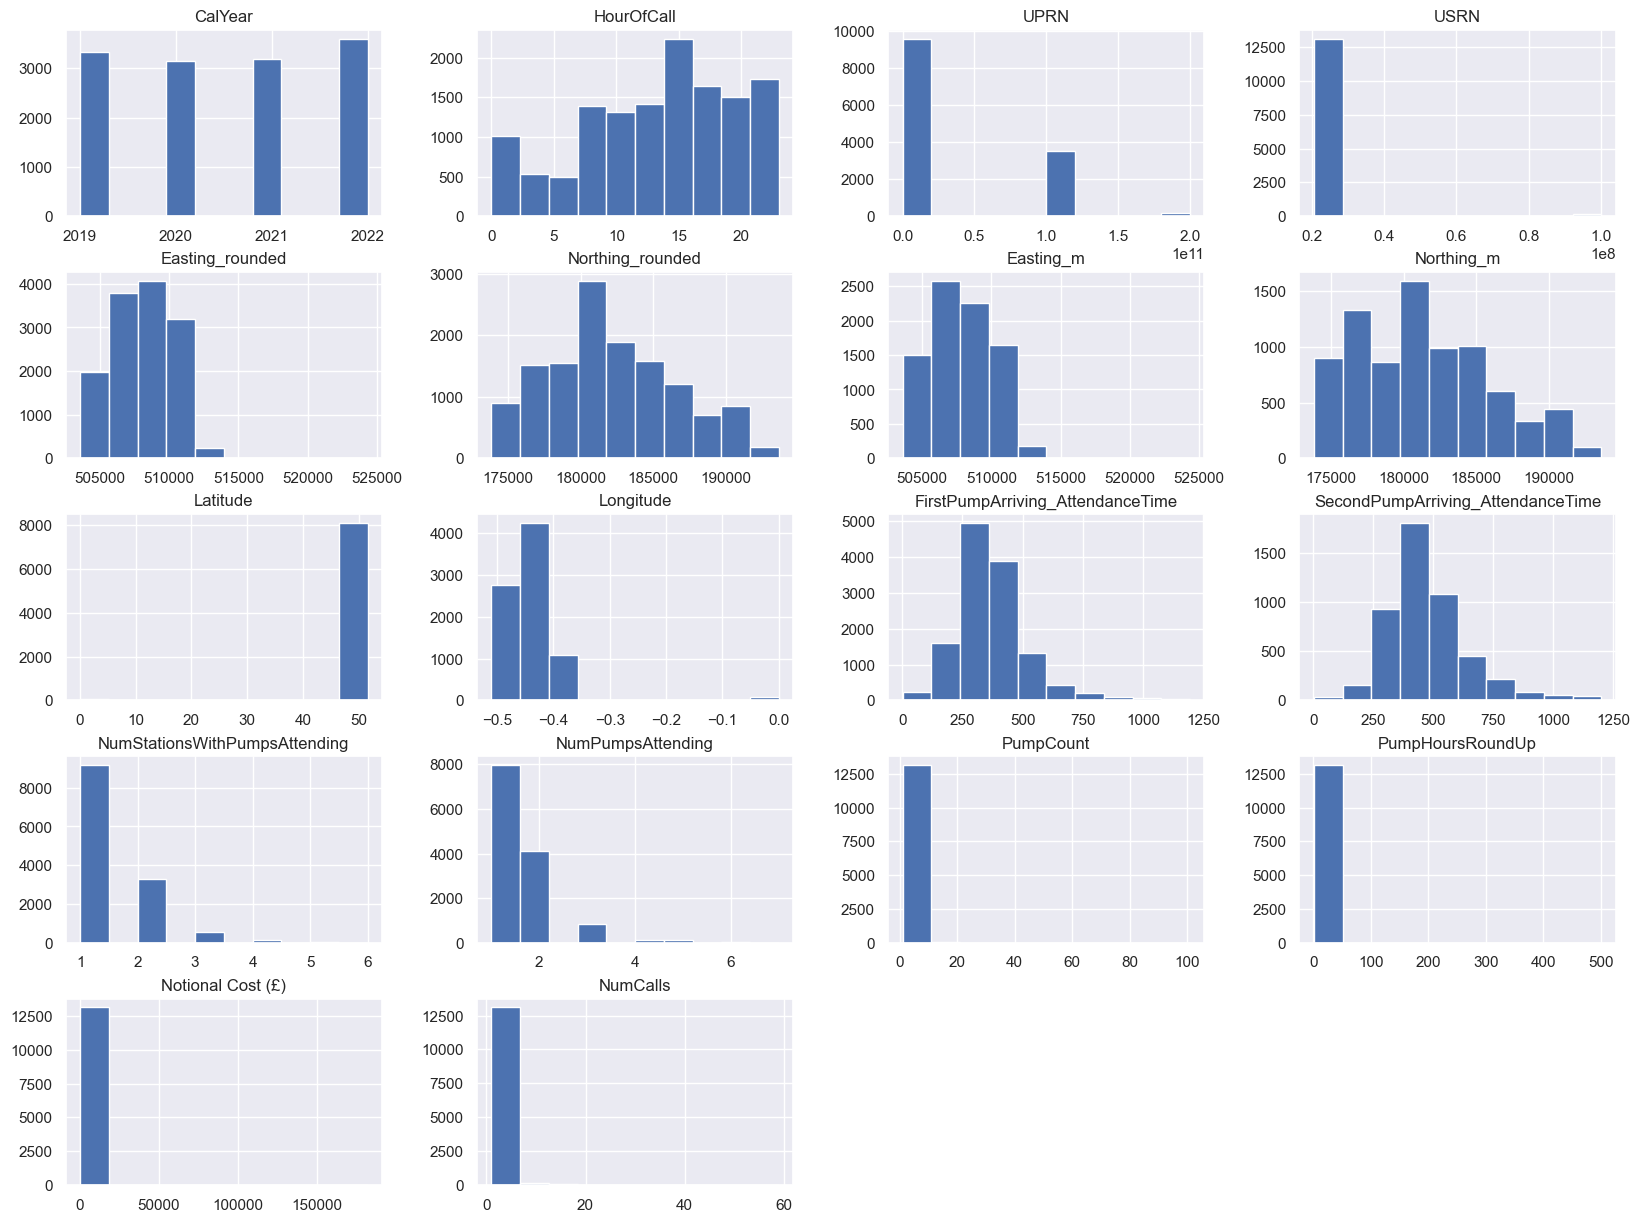

In [ ]:
# distribution of key attributes
new_df[num_col].hist(figsize=(20,15))
plt.show()

<AxesSubplot:xlabel='HourOfCall', ylabel='Count'>

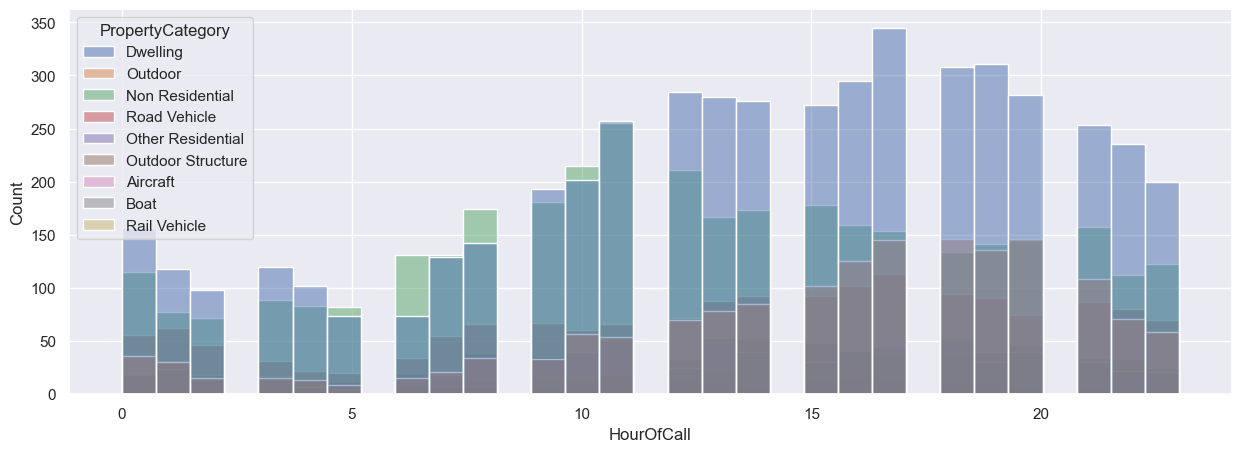

In [ ]:
plt.figure(figsize=(15,5))
sns.histplot(data=new_df, x='HourOfCall', hue='PropertyCategory')

<AxesSubplot:xlabel='Northing_m', ylabel='Count'>

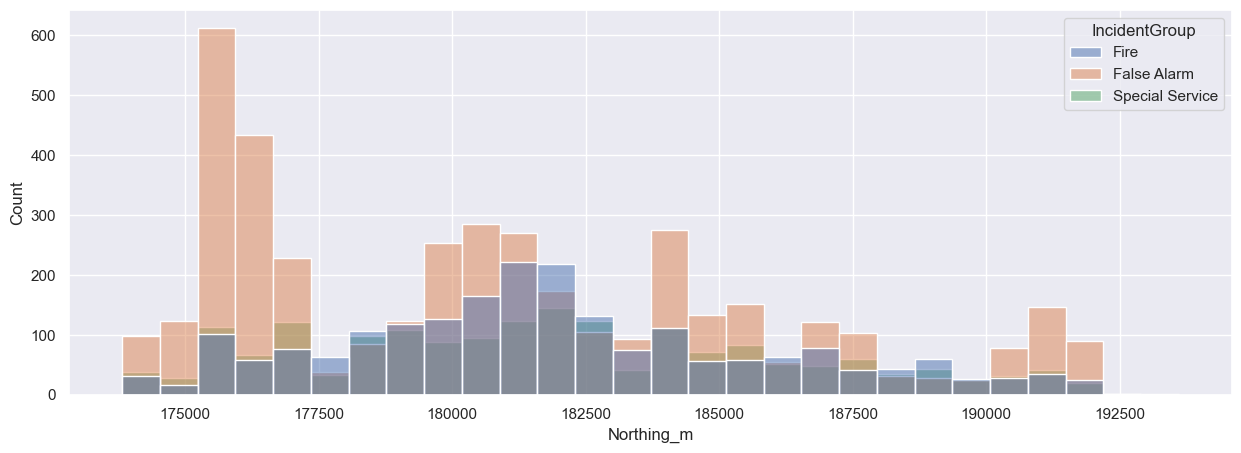

In [ ]:
plt.figure(figsize=(15,5))
sns.histplot(data=new_df, x='Northing_m', hue='IncidentGroup')

<AxesSubplot:xlabel='Easting_m', ylabel='Density'>

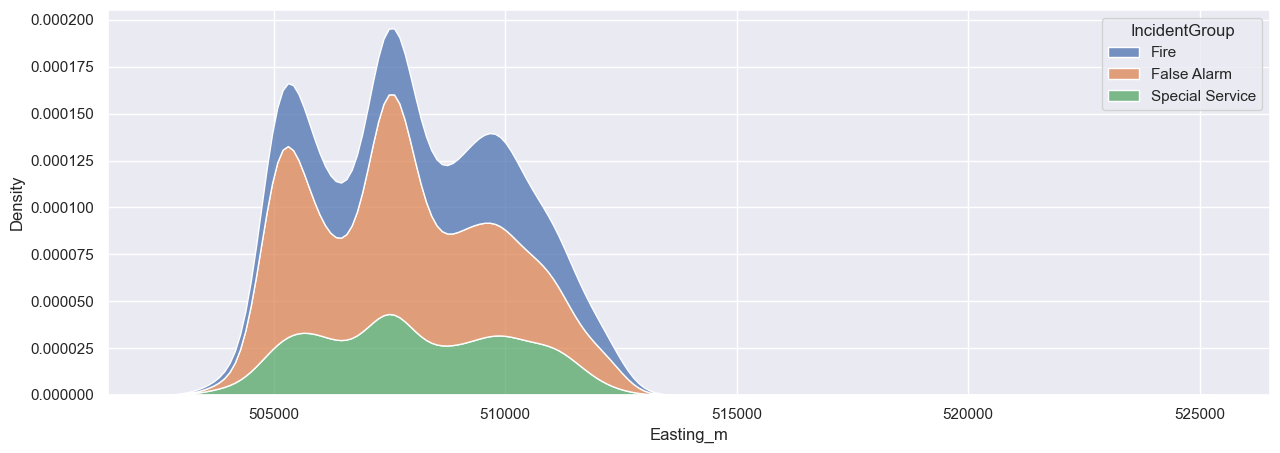

In [ ]:
plt.figure(figsize=(15,5))
sns.kdeplot(data=new_df, x='Easting_m', hue='IncidentGroup', multiple='stack')

<Figure size 1500x500 with 0 Axes>

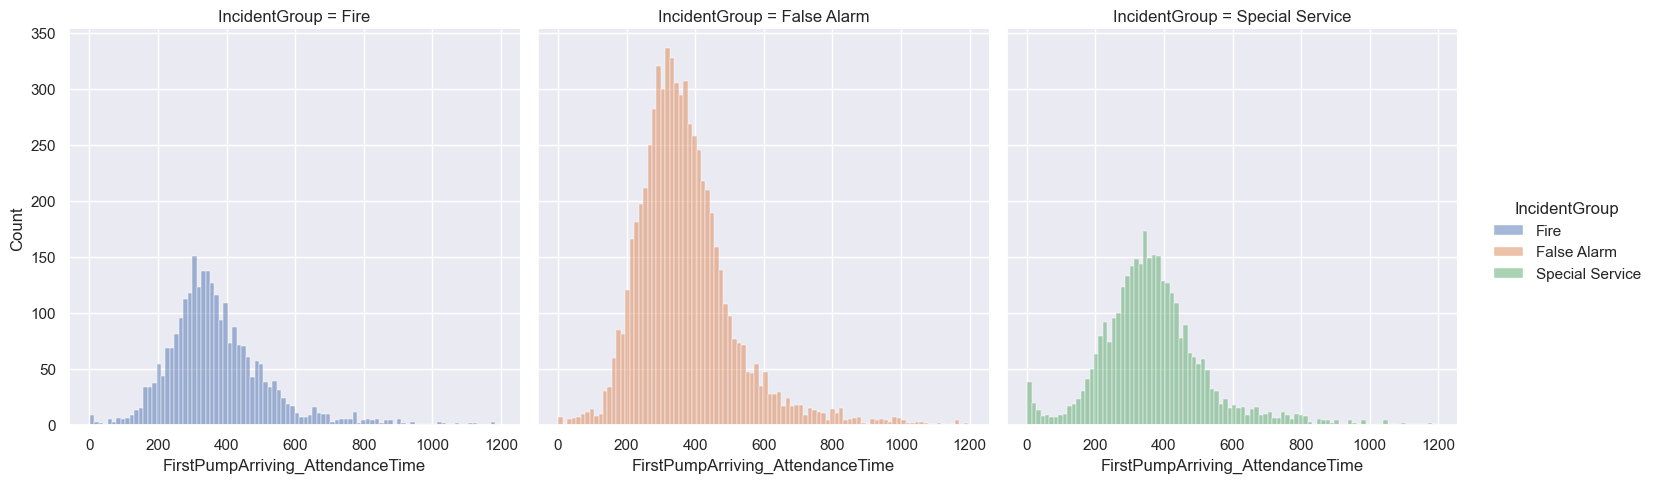

In [ ]:
plt.figure(figsize=(15,5))
sns.displot(data=new_df, x='FirstPumpArriving_AttendanceTime', hue='IncidentGroup', col='IncidentGroup')

<AxesSubplot:xlabel='NumCalls', ylabel='Count'>

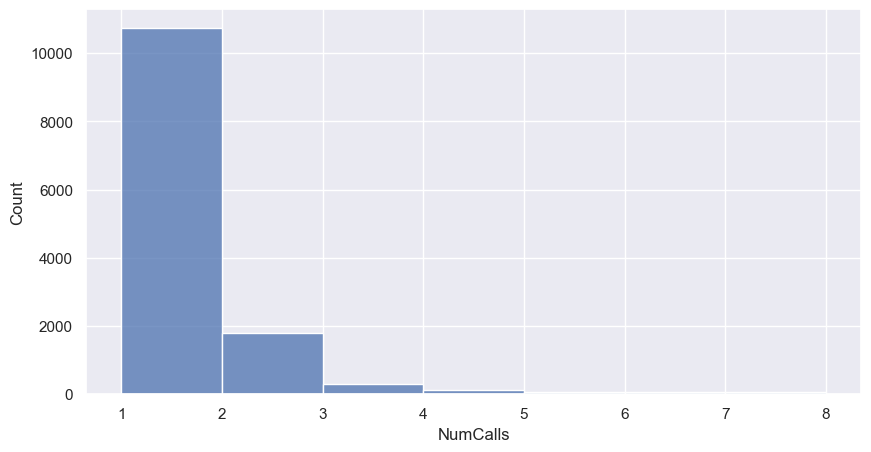

In [ ]:
plt.figure(figsize=(10,5))
sns.histplot(data=new_df, x='NumCalls', bins=[1,2,3,4,5,6,7,8])

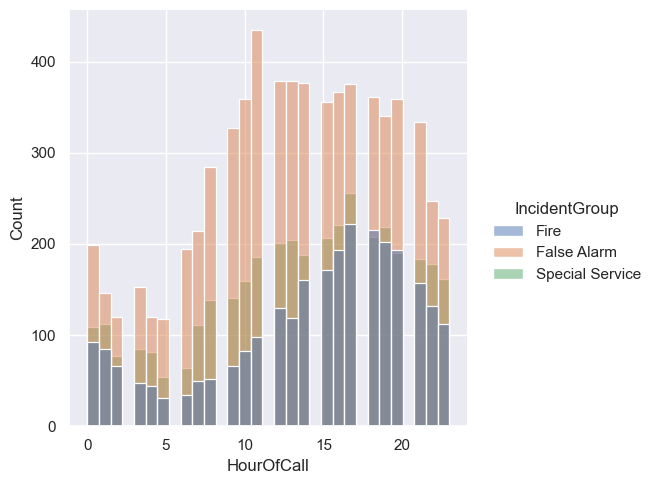

In [ ]:
# Cumulative Distributions
sns.displot(new_df, x='HourOfCall', hue='IncidentGroup')

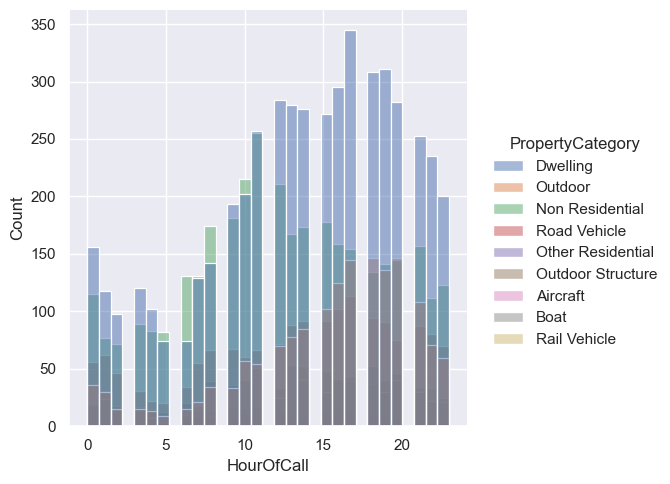

In [ ]:
sns.displot(new_df, x='HourOfCall', hue='PropertyCategory')

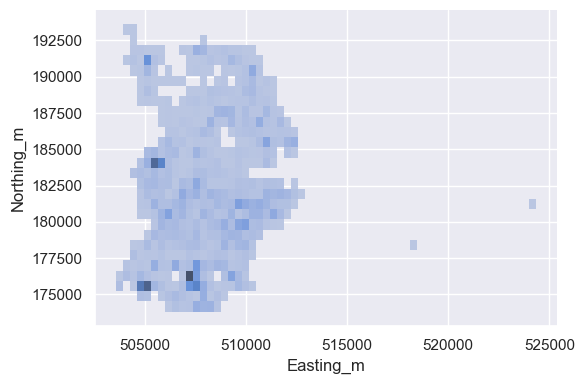

In [ ]:
# Bivariate distributions
sns.displot(new_df, x='Easting_m', y='Northing_m', height=4, aspect=1.5)

<AxesSubplot:xlabel='NumCalls'>

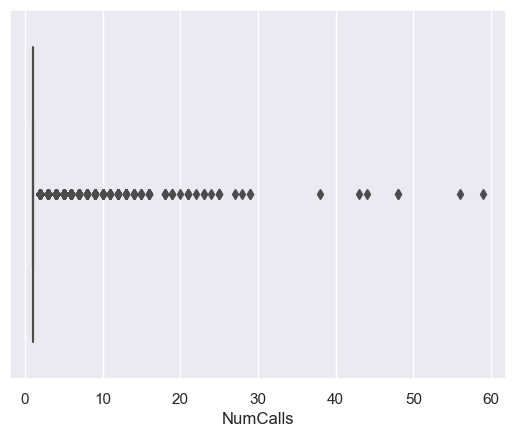

In [ ]:
# need to remove the cost outliers
sns.boxplot(new_df['NumCalls'])
# we will check all outlier and deal with them in 'Clean' step
# cleaned data will be used for further EDA and viz.

<AxesSubplot:xlabel='Notional Cost (£)'>

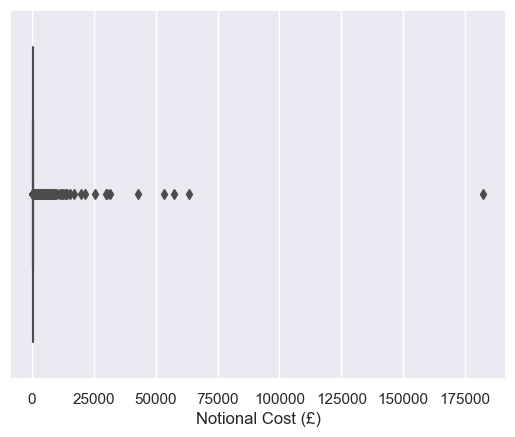

In [ ]:
# need to remove the cost outliers
sns.boxplot(new_df['Notional Cost (£)'])
# we will check all outlier and deal with them in 'Clean' step
# cleaned data will be used for further EDA and viz.

<AxesSubplot:xlabel='HourOfCall'>

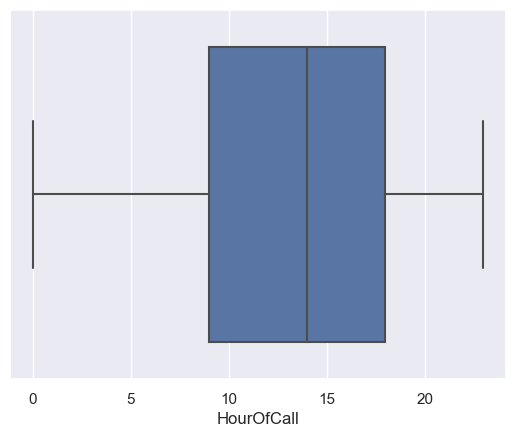

In [ ]:
# Boxplots
sns.boxplot(data=new_df, x='HourOfCall')

<AxesSubplot:xlabel='Northing_m'>

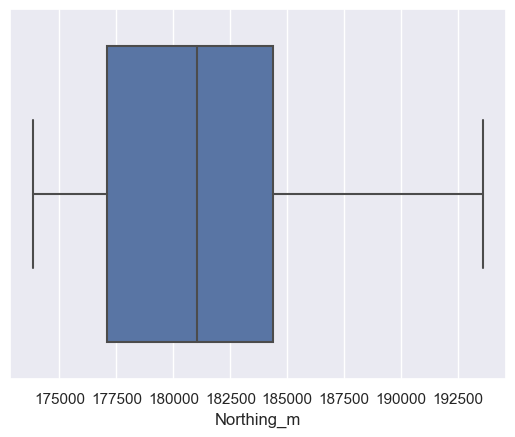

In [ ]:
sns.boxplot(data=new_df, x='Northing_m')

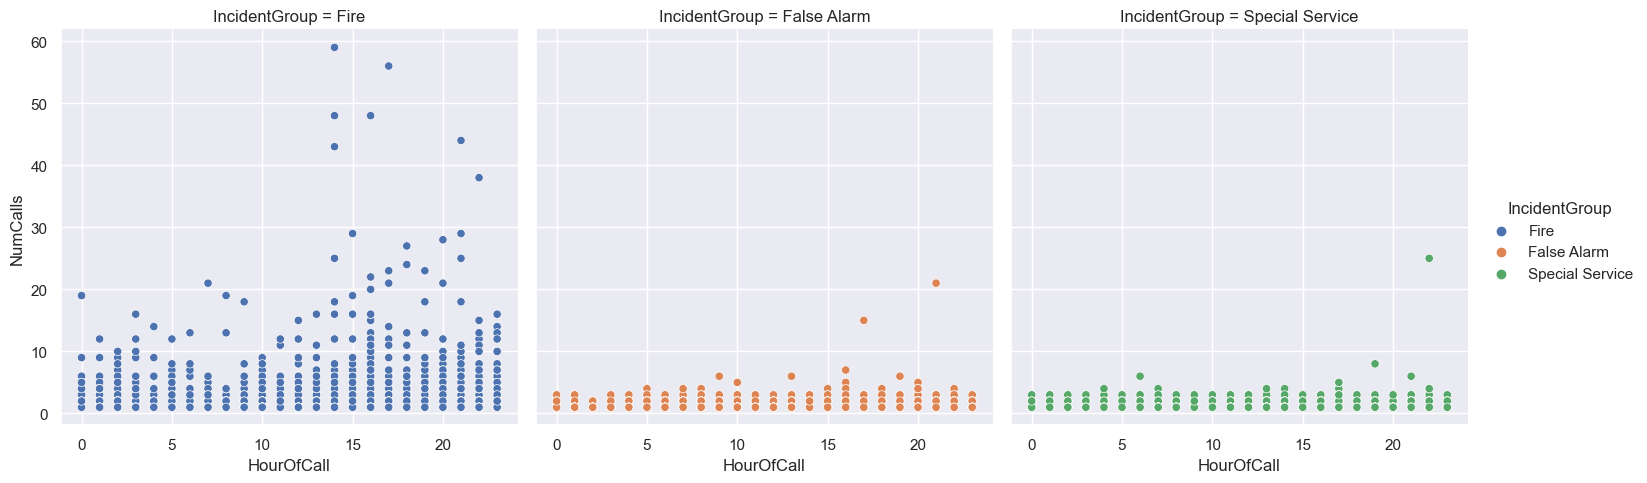

In [ ]:
# relationship plot - numeric vs numeric
sns.relplot(data=new_df, x='HourOfCall', y='NumCalls', hue='IncidentGroup', col='IncidentGroup')

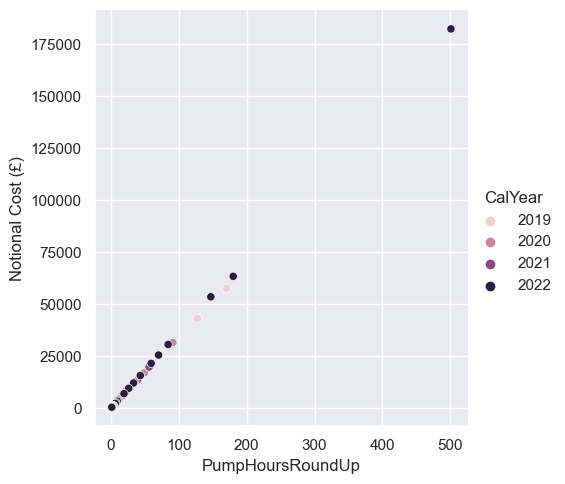

In [ ]:
sns.relplot(data=new_df, x='PumpHoursRoundUp', y='Notional Cost (£)', hue='CalYear')

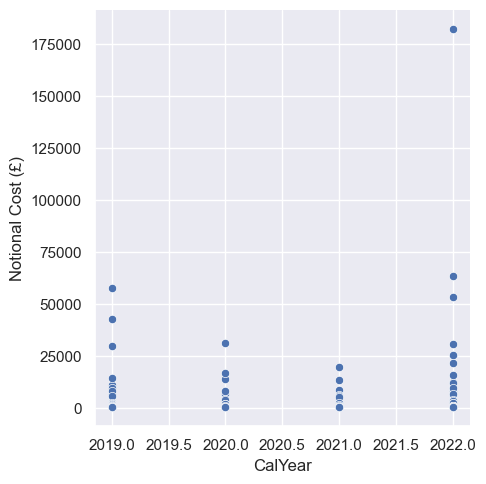

In [ ]:
sns.relplot(data=new_df, x='CalYear', y='Notional Cost (£)')

<AxesSubplot:xlabel='IncidentGroup', ylabel='count'>

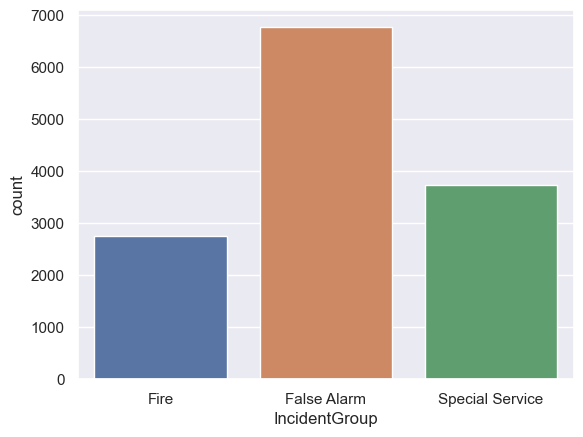

In [ ]:
# Categorical attributes exploration
sns.countplot(new_df['IncidentGroup'])

### Data quality

In [ ]:
# check for redundant columns
new_df.columns

Index(['IncidentNumber', 'DateOfCall', 'CalYear', 'TimeOfCall', 'HourOfCall',
       'IncidentGroup', 'StopCodeDescription', 'SpecialServiceType',
       'PropertyCategory', 'PropertyType', 'AddressQualifier', 'Postcode_full',
       'Postcode_district', 'UPRN', 'USRN', 'IncGeo_BoroughCode',
       'IncGeo_BoroughName', 'ProperCase', 'IncGeo_WardCode',
       'IncGeo_WardName', 'IncGeo_WardNameNew', 'Easting_m', 'Northing_m',
       'Easting_rounded', 'Northing_rounded', 'Latitude', 'Longitude', 'FRS',
       'IncidentStationGround', 'FirstPumpArriving_AttendanceTime',
       'FirstPumpArriving_DeployedFromStation',
       'SecondPumpArriving_AttendanceTime',
       'SecondPumpArriving_DeployedFromStation',
       'NumStationsWithPumpsAttending', 'NumPumpsAttending', 'PumpCount',
       'PumpHoursRoundUp', 'Notional Cost (£)', 'NumCalls'],
      dtype='object')

In [ ]:
redundant_columns = ['IncGeo_BoroughCode', 'ProperCase', 'IncGeo_WardCode', 'IncGeo_WardName', 'Easting_m', 'Northing_m', 'FRS']
irrelevant_columns = ['UPRN', 'USRN']
privacy_columns = ['AddressQualifier', 'Postcode_full']
removable_columns = redundant_columns + irrelevant_columns + privacy_columns

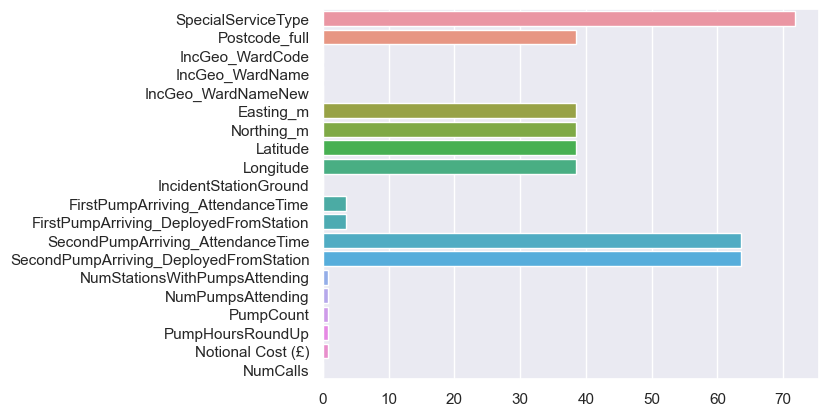

In [ ]:
# check for missing values
missing = [(col, new_df[col].isna().sum()) for col in df.columns if df[col].isna().sum()>0]
missing_x = [i[0] for i in missing]
missing_y = [(i[1]/len(new_df))*100 for i in missing]
sns.barplot(x=missing_y, y=missing_x, orient='horizontal')
plt.show()

In [ ]:
missing

[('SpecialServiceType', 9530),
 ('Postcode_full', 5101),
 ('IncGeo_WardCode', 0),
 ('IncGeo_WardName', 0),
 ('IncGeo_WardNameNew', 0),
 ('Easting_m', 5101),
 ('Northing_m', 5101),
 ('Latitude', 5101),
 ('Longitude', 5101),
 ('IncidentStationGround', 0),
 ('FirstPumpArriving_AttendanceTime', 464),
 ('FirstPumpArriving_DeployedFromStation', 464),
 ('SecondPumpArriving_AttendanceTime', 8434),
 ('SecondPumpArriving_DeployedFromStation', 8434),
 ('NumStationsWithPumpsAttending', 114),
 ('NumPumpsAttending', 114),
 ('PumpCount', 101),
 ('PumpHoursRoundUp', 105),
 ('Notional Cost (£)', 105),
 ('NumCalls', 0)]

In [ ]:
# check for duplicates
# duplicated columns - None
# duplicated rows
new_df.duplicated().value_counts

<bound method IndexOpsMixin.value_counts of 60        False
115       False
148       False
185       False
203       False
          ...  
426263    False
426307    False
426321    False
426325    False
426415    False
Length: 13267, dtype: bool>

In [ ]:
# check for outliers (numeric)
def detect_outliers(new_df, numeric_cols, iqr_threshold=1.5, z_score_threshold=3):
    """
    Detect ouliters with appropriate method for each column.
    Use IQR if missing values OR skewed distribution.
    Use z-score if no missing and normal distribution.
    """
    outliers = pd.DataFrame()
    for col in numeric_cols:  # numeric columns
        if abs(new_df[col].skew()) < 1:  # normal dist
            z_score = abs((new_df[col] - new_df[col].mean()) / new_df[col].std(ddof=0))
            threshold = z_score_threshold
            outliers[col] = np.where(z_score > threshold, True, False)
        else:  # skewed dist
            q1 = new_df[col].quantile(0.25)
            q3 = new_df[col].quantile(0.75)
            iqr = q3 - q1
            thresh = iqr_threshold
            lower_bound = q1 - thresh * iqr
            upper_bound = q3 + thresh * iqr
            outliers[col] = np.where((new_df[col] < lower_bound) | (new_df[col] > upper_bound), True, False)
    return outliers

In [ ]:
outliers = detect_outliers(new_df, num_col)
outliers

,CalYear,HourOfCall,UPRN,USRN,Easting_rounded,Northing_rounded,Easting_m,Northing_m,Latitude,Longitude,FirstPumpArriving_AttendanceTime,SecondPumpArriving_AttendanceTime,NumStationsWithPumpsAttending,NumPumpsAttending,PumpCount,PumpHoursRoundUp,Notional Cost (£),NumCalls
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,True,True
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13262,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
13263,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
13264,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False
13265,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True


In [ ]:
outlier_count = outliers.apply(pd.value_counts)
outlier_count

,CalYear,HourOfCall,UPRN,USRN,Easting_rounded,Northing_rounded,Easting_m,Northing_m,Latitude,Longitude,FirstPumpArriving_AttendanceTime,SecondPumpArriving_AttendanceTime,NumStationsWithPumpsAttending,NumPumpsAttending,PumpCount,PumpHoursRoundUp,Notional Cost (£),NumCalls
False,13267.0,13267.0,13267.0,13107,13265,13267.0,13265,13267.0,13181,13179,12599,13027,13095,13007,12912,11200,11200,10749
True,NaN,NaN,NaN,160,2,NaN,2,NaN,86,88,668,240,172,260,355,2067,2067,2518


In [ ]:
outlier_count.index = ['Normal', 'Outlier']
outlier_count.fillna(0, inplace=True)
outlier_count

,CalYear,HourOfCall,UPRN,USRN,Easting_rounded,Northing_rounded,Easting_m,Northing_m,Latitude,Longitude,FirstPumpArriving_AttendanceTime,SecondPumpArriving_AttendanceTime,NumStationsWithPumpsAttending,NumPumpsAttending,PumpCount,PumpHoursRoundUp,Notional Cost (£),NumCalls
Normal,13267.0,13267.0,13267.0,13107,13265,13267.0,13265,13267.0,13181,13179,12599,13027,13095,13007,12912,11200,11200,10749
Outlier,0.0,0.0,0.0,160,2,0.0,2,0.0,86,88,668,240,172,260,355,2067,2067,2518


In [ ]:
# bring it all into a function
def count_outliers(outliers):
    outlier_count = outliers.apply(pd.value_counts)
    outlier_count.index = ['Normal', 'Outlier']
    outlier_count.fillna(0, inplace=True)
    return outlier_count

In [ ]:
# convert wide to long format
outlier_count_long = outlier_count.reset_index().melt(id_vars='index', var_name='column', value_name='value')
outlier_count_long[:5]

,index,column,value
0,Normal,CalYear,13267.0
1,Outlier,CalYear,0.0
2,Normal,HourOfCall,13267.0
3,Outlier,HourOfCall,0.0
4,Normal,UPRN,13267.0


In [ ]:
plt.figure(figsize=(10, 6))
ax = sns.barplot(outlier_count_long, x='value', y='column', hue='index', dodge=False)
ax.set_title('The proportion of outliers in numeric attribute')

ValueError: Could not interpret input 'column'

<Figure size 1000x600 with 0 Axes>

# Data Preperation

## mising values

In [ ]:
new_df.isnull()

,IncidentNumber,DateOfCall,CalYear,TimeOfCall,HourOfCall,IncidentGroup,StopCodeDescription,SpecialServiceType,PropertyCategory,PropertyType,...,FirstPumpArriving_AttendanceTime,FirstPumpArriving_DeployedFromStation,SecondPumpArriving_AttendanceTime,SecondPumpArriving_DeployedFromStation,NumStationsWithPumpsAttending,NumPumpsAttending,PumpCount,PumpHoursRoundUp,Notional Cost (£),NumCalls
60,False,False,False,False,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
115,False,False,False,False,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
148,False,False,False,False,False,False,False,False,False,False,...,True,True,True,True,True,True,True,True,True,False
185,False,False,False,False,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
203,False,False,False,False,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
426263,False,False,False,False,False,False,False,True,False,False,...,False,False,True,True,False,False,False,False,False,False
426307,False,False,False,False,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
426321,False,False,False,False,False,False,False,True,False,False,...,False,False,True,True,False,False,False,False,False,False
426325,False,False,False,False,False,False,False,True,False,False,...,False,False,True,True,False,False,False,False,False,False


In [ ]:
new_df.shape

(13267, 39)

In [ ]:
new_df.isnull().sum()

IncidentNumber                               0
DateOfCall                                   0
CalYear                                      0
TimeOfCall                                   0
HourOfCall                                   0
IncidentGroup                                0
StopCodeDescription                          0
SpecialServiceType                        9530
PropertyCategory                             0
PropertyType                                 0
AddressQualifier                             0
Postcode_full                             5101
Postcode_district                            0
UPRN                                         0
USRN                                         0
IncGeo_BoroughCode                           0
IncGeo_BoroughName                           0
ProperCase                                   0
IncGeo_WardCode                              0
IncGeo_WardName                              0
IncGeo_WardNameNew                           0
Easting_m    

In [ ]:
#Treat minning values with mean
new_df=new_df.fillna(value=df['SecondPumpArriving_AttendanceTime'].mean())
new_df

,IncidentNumber,DateOfCall,CalYear,TimeOfCall,HourOfCall,IncidentGroup,StopCodeDescription,SpecialServiceType,PropertyCategory,PropertyType,...,FirstPumpArriving_AttendanceTime,FirstPumpArriving_DeployedFromStation,SecondPumpArriving_AttendanceTime,SecondPumpArriving_DeployedFromStation,NumStationsWithPumpsAttending,NumPumpsAttending,PumpCount,PumpHoursRoundUp,Notional Cost (£),NumCalls
60,000200-01012019,01 Jan 2019,2019,01:15:12,1,Fire,Primary Fire,389.584009,Dwelling,House - single occupancy,...,357.000000,Southall,529.000000,Northolt,2.000000,2.000000,2.000000,2.000000,666.000000,2.0
115,000344-01012019,01 Jan 2019,2019,05:51:14,5,False Alarm,AFA,389.584009,Dwelling,Converted Flat/Maisonette - Up to 2 storeys,...,437.000000,Harrow,442.000000,Ruislip,2.000000,2.000000,2.000000,1.000000,333.000000,1.0
148,000408-01012019,01 Jan 2019,2019,10:25:01,10,Special Service,Special Service,No action (not false alarm),Outdoor,Lake/pond/reservoir,...,389.584009,389.584009,389.584009,389.584009,389.584009,389.584009,389.584009,389.584009,389.584009,2.0
185,000465-01012019,01 Jan 2019,2019,14:14:03,14,False Alarm,AFA,389.584009,Non Residential,Airport - terminal,...,575.000000,Hayes,364.000000,Feltham,2.000000,3.000000,3.000000,1.000000,333.000000,1.0
203,000496-01012019,01 Jan 2019,2019,15:50:35,15,Fire,Primary Fire,389.584009,Dwelling,Converted Flat/Maisonette - Up to 2 storeys,...,364.000000,Hillingdon,370.000000,Hillingdon,1.000000,2.000000,2.000000,1.000000,333.000000,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
426263,195344-30112022,30 Nov 2022,2022,11:37:36,11,False Alarm,AFA,389.584009,Non Residential,Train station - platform (below ground),...,216.000000,Heathrow,389.584009,389.584009,1.000000,1.000000,1.000000,1.000000,364.000000,1.0
426307,195407-30112022,30 Nov 2022,2022,13:44:05,13,Fire,Primary Fire,389.584009,Dwelling,House - single occupancy,...,360.000000,Hillingdon,361.000000,Hillingdon,1.000000,2.000000,2.000000,1.000000,364.000000,1.0
426321,195427-30112022,30 Nov 2022,2022,14:35:45,14,False Alarm,False alarm - Good intent,389.584009,Outdoor,Domestic garden (vegetation not equipment),...,828.000000,Hillingdon,389.584009,389.584009,1.000000,1.000000,1.000000,1.000000,364.000000,1.0
426325,195433-30112022,30 Nov 2022,2022,14:53:53,14,False Alarm,AFA,389.584009,Dwelling,Self contained Sheltered Housing,...,735.000000,Northolt,389.584009,389.584009,1.000000,1.000000,1.000000,1.000000,364.000000,2.0


In [ ]:
new_df.isnull().sum()

IncidentNumber                            0
DateOfCall                                0
CalYear                                   0
TimeOfCall                                0
HourOfCall                                0
IncidentGroup                             0
StopCodeDescription                       0
SpecialServiceType                        0
PropertyCategory                          0
PropertyType                              0
AddressQualifier                          0
Postcode_full                             0
Postcode_district                         0
UPRN                                      0
USRN                                      0
IncGeo_BoroughCode                        0
IncGeo_BoroughName                        0
ProperCase                                0
IncGeo_WardCode                           0
IncGeo_WardName                           0
IncGeo_WardNameNew                        0
Easting_m                                 0
Northing_m                      

In [ ]:
new_df

,IncidentNumber,DateOfCall,CalYear,TimeOfCall,HourOfCall,IncidentGroup,StopCodeDescription,SpecialServiceType,PropertyCategory,PropertyType,...,FirstPumpArriving_AttendanceTime,FirstPumpArriving_DeployedFromStation,SecondPumpArriving_AttendanceTime,SecondPumpArriving_DeployedFromStation,NumStationsWithPumpsAttending,NumPumpsAttending,PumpCount,PumpHoursRoundUp,Notional Cost (£),NumCalls
60,000200-01012019,01 Jan 2019,2019,01:15:12,1,Fire,Primary Fire,389.584009,Dwelling,House - single occupancy,...,357.000000,Southall,529.000000,Northolt,2.000000,2.000000,2.000000,2.000000,666.000000,2.0
115,000344-01012019,01 Jan 2019,2019,05:51:14,5,False Alarm,AFA,389.584009,Dwelling,Converted Flat/Maisonette - Up to 2 storeys,...,437.000000,Harrow,442.000000,Ruislip,2.000000,2.000000,2.000000,1.000000,333.000000,1.0
148,000408-01012019,01 Jan 2019,2019,10:25:01,10,Special Service,Special Service,No action (not false alarm),Outdoor,Lake/pond/reservoir,...,389.584009,389.584009,389.584009,389.584009,389.584009,389.584009,389.584009,389.584009,389.584009,2.0
185,000465-01012019,01 Jan 2019,2019,14:14:03,14,False Alarm,AFA,389.584009,Non Residential,Airport - terminal,...,575.000000,Hayes,364.000000,Feltham,2.000000,3.000000,3.000000,1.000000,333.000000,1.0
203,000496-01012019,01 Jan 2019,2019,15:50:35,15,Fire,Primary Fire,389.584009,Dwelling,Converted Flat/Maisonette - Up to 2 storeys,...,364.000000,Hillingdon,370.000000,Hillingdon,1.000000,2.000000,2.000000,1.000000,333.000000,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
426263,195344-30112022,30 Nov 2022,2022,11:37:36,11,False Alarm,AFA,389.584009,Non Residential,Train station - platform (below ground),...,216.000000,Heathrow,389.584009,389.584009,1.000000,1.000000,1.000000,1.000000,364.000000,1.0
426307,195407-30112022,30 Nov 2022,2022,13:44:05,13,Fire,Primary Fire,389.584009,Dwelling,House - single occupancy,...,360.000000,Hillingdon,361.000000,Hillingdon,1.000000,2.000000,2.000000,1.000000,364.000000,1.0
426321,195427-30112022,30 Nov 2022,2022,14:35:45,14,False Alarm,False alarm - Good intent,389.584009,Outdoor,Domestic garden (vegetation not equipment),...,828.000000,Hillingdon,389.584009,389.584009,1.000000,1.000000,1.000000,1.000000,364.000000,1.0
426325,195433-30112022,30 Nov 2022,2022,14:53:53,14,False Alarm,AFA,389.584009,Dwelling,Self contained Sheltered Housing,...,735.000000,Northolt,389.584009,389.584009,1.000000,1.000000,1.000000,1.000000,364.000000,2.0


In [ ]:
new_df.columns

Index(['IncidentNumber', 'DateOfCall', 'CalYear', 'TimeOfCall', 'HourOfCall',
       'IncidentGroup', 'StopCodeDescription', 'SpecialServiceType',
       'PropertyCategory', 'PropertyType', 'AddressQualifier', 'Postcode_full',
       'Postcode_district', 'UPRN', 'USRN', 'IncGeo_BoroughCode',
       'IncGeo_BoroughName', 'ProperCase', 'IncGeo_WardCode',
       'IncGeo_WardName', 'IncGeo_WardNameNew', 'Easting_m', 'Northing_m',
       'Easting_rounded', 'Northing_rounded', 'Latitude', 'Longitude', 'FRS',
       'IncidentStationGround', 'FirstPumpArriving_AttendanceTime',
       'FirstPumpArriving_DeployedFromStation',
       'SecondPumpArriving_AttendanceTime',
       'SecondPumpArriving_DeployedFromStation',
       'NumStationsWithPumpsAttending', 'NumPumpsAttending', 'PumpCount',
       'PumpHoursRoundUp', 'Notional Cost (£)', 'NumCalls'],
      dtype='object')

In [ ]:
print(len(new_df))

13267


## outliers

In [ ]:
# numeric outliers
numeric_cols = [col for col in new_df.columns if new_df[col].dtype!=object]
outliers = detect_outliers(new_df, numeric_cols)
outliers.head()

,CalYear,HourOfCall,UPRN,USRN,Easting_m,Northing_m,Easting_rounded,Northing_rounded,Latitude,Longitude,FirstPumpArriving_AttendanceTime,SecondPumpArriving_AttendanceTime,NumStationsWithPumpsAttending,NumPumpsAttending,PumpCount,PumpHoursRoundUp,Notional Cost (£),NumCalls
0,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,True,True,True
1,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,True,True,True,True,False,True
3,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True


In [ ]:
count_outliers(outliers)

,CalYear,HourOfCall,UPRN,USRN,Easting_m,Northing_m,Easting_rounded,Northing_rounded,Latitude,Longitude,FirstPumpArriving_AttendanceTime,SecondPumpArriving_AttendanceTime,NumStationsWithPumpsAttending,NumPumpsAttending,PumpCount,PumpHoursRoundUp,Notional Cost (£),NumCalls
Normal,13267.0,13267.0,13267.0,13107,13267.0,13267.0,13265,13267.0,13267.0,13267.0,12531,8462,12981,12893,12811,11095,11200,10749
Outlier,0.0,0.0,0.0,160,0.0,0.0,2,0.0,0.0,0.0,736,4805,286,374,456,2172,2067,2518


In [ ]:
# if we were to drop all outliers, how many records would we lose?
rows_with_outliers = []
for idx in list(outliers.index):
    if (outliers.iloc[idx] == True).sum() > 0:
        rows_with_outliers.append(idx)

len(rows_with_outliers)

7337

In [ ]:
# percentage of data lost in outlier removal
(len(rows_with_outliers)/len(new_df))*100

55.30263058717117

In [ ]:
rows_with_outliers[:11]

[0, 1, 2, 3, 4, 5, 7, 10, 11, 12, 14]

In [ ]:
outliers.loc[[0,5,8]]

,CalYear,HourOfCall,UPRN,USRN,Easting_m,Northing_m,Easting_rounded,Northing_rounded,Latitude,Longitude,FirstPumpArriving_AttendanceTime,SecondPumpArriving_AttendanceTime,NumStationsWithPumpsAttending,NumPumpsAttending,PumpCount,PumpHoursRoundUp,Notional Cost (£),NumCalls
0,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,True,True,True
5,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False
8,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [ ]:
outliers.tail(6)

,CalYear,HourOfCall,UPRN,USRN,Easting_m,Northing_m,Easting_rounded,Northing_rounded,Latitude,Longitude,FirstPumpArriving_AttendanceTime,SecondPumpArriving_AttendanceTime,NumStationsWithPumpsAttending,NumPumpsAttending,PumpCount,PumpHoursRoundUp,Notional Cost (£),NumCalls
13261,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
13262,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
13263,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False
13264,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False
13265,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True
13266,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True


In [ ]:
print(len(new_df), len(outliers))
print(outliers.index[-5:])
print(new_df.index[-5:])

13267 13267
RangeIndex(start=13262, stop=13267, step=1)
Int64Index([426263, 426307, 426321, 426325, 426415], dtype='int64')


In [ ]:
# outliers and df have same num of rows but numbered differently
# to remove the rows by the indices listed in rows_with_outliers:
# lets reindex df with 0 to 420295 (i.e. serial num)
new_df.reset_index(drop=True, inplace=True)

In [ ]:
new_df.tail(3)

,IncidentNumber,DateOfCall,CalYear,TimeOfCall,HourOfCall,IncidentGroup,StopCodeDescription,SpecialServiceType,PropertyCategory,PropertyType,...,FirstPumpArriving_AttendanceTime,FirstPumpArriving_DeployedFromStation,SecondPumpArriving_AttendanceTime,SecondPumpArriving_DeployedFromStation,NumStationsWithPumpsAttending,NumPumpsAttending,PumpCount,PumpHoursRoundUp,Notional Cost (£),NumCalls
13264,195427-30112022,30 Nov 2022,2022,14:35:45,14,False Alarm,False alarm - Good intent,389.584009,Outdoor,Domestic garden (vegetation not equipment),...,828.0,Hillingdon,389.584009,389.584009,1.0,1.0,1.0,1.0,364.0,1.0
13265,195433-30112022,30 Nov 2022,2022,14:53:53,14,False Alarm,AFA,389.584009,Dwelling,Self contained Sheltered Housing,...,735.0,Northolt,389.584009,389.584009,1.0,1.0,1.0,1.0,364.0,2.0
13266,195570-30112022,30 Nov 2022,2022,19:43:13,19,Fire,Primary Fire,389.584009,Road Vehicle,Car,...,462.0,Southall,389.584009,389.584009,1.0,1.0,1.0,1.0,364.0,13.0


In [ ]:
# !!! let's remove the outliers
#df.drop(rows_with_outliers, inplace=True)

In [ ]:
new_df.shape

(13267, 39)

### Transform

#### Derived attributes

In [ ]:
new_df.columns

Index(['IncidentNumber', 'DateOfCall', 'CalYear', 'TimeOfCall', 'HourOfCall',
       'IncidentGroup', 'StopCodeDescription', 'SpecialServiceType',
       'PropertyCategory', 'PropertyType', 'AddressQualifier', 'Postcode_full',
       'Postcode_district', 'UPRN', 'USRN', 'IncGeo_BoroughCode',
       'IncGeo_BoroughName', 'ProperCase', 'IncGeo_WardCode',
       'IncGeo_WardName', 'IncGeo_WardNameNew', 'Easting_m', 'Northing_m',
       'Easting_rounded', 'Northing_rounded', 'Latitude', 'Longitude', 'FRS',
       'IncidentStationGround', 'FirstPumpArriving_AttendanceTime',
       'FirstPumpArriving_DeployedFromStation',
       'SecondPumpArriving_AttendanceTime',
       'SecondPumpArriving_DeployedFromStation',
       'NumStationsWithPumpsAttending', 'NumPumpsAttending', 'PumpCount',
       'PumpHoursRoundUp', 'Notional Cost (£)', 'NumCalls'],
      dtype='object')

In [ ]:
# creating a 'day' column from 'date' for the day of the week
new_df['day'] = new_df['date'].apply(lambda x: pd.to_datetime(x).day_name())
new_df['day'][:3]

KeyError: 'date'

### Scaling

In [ ]:
new_df[numeric_cols].describe()

,CalYear,HourOfCall,UPRN,USRN,Easting_m,Northing_m,Easting_rounded,Northing_rounded,Latitude,Longitude,FirstPumpArriving_AttendanceTime,SecondPumpArriving_AttendanceTime,NumStationsWithPumpsAttending,NumPumpsAttending,PumpCount,PumpHoursRoundUp,Notional Cost (£),NumCalls
count,13267.000000,13267.000000,1.326700e+04,1.326700e+04,13267.000000,13267.000000,13267.000000,13267.000000,13267.000000,13267.000000,13267.000000,13267.000000,13267.000000,13267.000000,13267.000000,13267.000000,13267.000000,13267.00000
mean,2020.533127,13.407251,3.220999e+10,2.217676e+07,312807.267885,111787.266151,508161.803724,182181.212784,181.168431,149.519254,371.890026,420.789216,4.709774,4.841530,4.527775,4.527800,507.943418,1.40710
std,1.137541,6.209801,4.651034e+10,7.770994e+06,246935.976491,88121.123144,2051.139706,4439.753199,164.780470,189.743871,145.833033,110.065697,35.838118,35.827804,33.758660,34.844149,2003.670995,1.80974
min,2019.000000,0.000000,0.000000e+00,2.060403e+07,389.584009,389.584009,503550.000000,173850.000000,0.000000,-0.510155,1.000000,2.000000,1.000000,1.000000,1.000000,1.000000,333.000000,1.00000
25%,2019.000000,9.000000,0.000000e+00,2.140073e+07,389.584009,389.584009,506350.000000,179250.000000,51.508875,-0.454633,285.000000,389.584009,1.000000,1.000000,1.000000,1.000000,339.000000,1.00000
50%,2021.000000,14.000000,1.002280e+10,2.140134e+07,505667.000000,176075.000000,508150.000000,181650.000000,51.558971,-0.413000,357.000000,389.584009,1.000000,1.000000,1.000000,1.000000,352.000000,1.00000
75%,2022.000000,18.000000,1.000214e+11,2.140203e+07,508404.000000,181919.000000,509850.000000,185050.000000,389.584009,389.584009,432.000000,390.000000,2.000000,2.000000,2.000000,1.000000,364.000000,1.00000
max,2022.000000,23.000000,2.000030e+11,9.999012e+07,524352.000000,193607.000000,524350.000000,193650.000000,389.584009,389.584009,1196.000000,1200.000000,389.584009,389.584009,389.584009,501.000000,182364.000000,59.00000


In [ ]:
scaler = StandardScaler()
new_df[numeric_cols] = scaler.fit_transform(new_df[numeric_cols])

In [ ]:
new_df.describe()

,CalYear,HourOfCall,UPRN,USRN,Easting_m,Northing_m,Easting_rounded,Northing_rounded,Latitude,Longitude,FirstPumpArriving_AttendanceTime,SecondPumpArriving_AttendanceTime,NumStationsWithPumpsAttending,NumPumpsAttending,PumpCount,PumpHoursRoundUp,Notional Cost (£),NumCalls
count,1.326700e+04,1.326700e+04,1.326700e+04,1.326700e+04,1.326700e+04,1.326700e+04,1.326700e+04,1.326700e+04,1.326700e+04,1.326700e+04,1.326700e+04,1.326700e+04,1.326700e+04,1.326700e+04,1.326700e+04,1.326700e+04,1.326700e+04,1.326700e+04
mean,-4.722218e-14,9.629994e-16,1.625727e-15,7.837336e-17,1.015745e-16,-1.416545e-15,-1.109085e-14,6.732082e-16,-1.939656e-15,-2.513136e-15,6.303844e-17,-1.463290e-15,-5.302930e-15,2.742149e-15,1.091792e-16,-7.141491e-16,-2.156533e-16,5.781495e-16
std,1.000038e+00,1.000038e+00,1.000038e+00,1.000038e+00,1.000038e+00,1.000038e+00,1.000038e+00,1.000038e+00,1.000038e+00,1.000038e+00,1.000038e+00,1.000038e+00,1.000038e+00,1.000038e+00,1.000038e+00,1.000038e+00,1.000038e+00,1.000038e+00
min,-1.347807e+00,-2.159128e+00,-6.925600e-01,-2.023926e-01,-1.265225e+00,-1.264190e+00,-2.248495e+00,-1.876574e+00,-1.099495e+00,-7.907242e-01,-2.543347e+00,-3.805046e+00,-1.035187e-01,-1.072261e-01,-1.045038e-01,-1.012489e-01,-8.731474e-02,-2.249581e-01
25%,-1.347807e+00,-7.097517e-01,-6.925600e-01,-9.986594e-02,-1.265225e+00,-1.264190e+00,-8.833489e-01,-6.602446e-01,-7.868921e-01,-7.904315e-01,-5.958410e-01,-2.835251e-01,-1.035187e-01,-1.072261e-01,-1.045038e-01,-1.012489e-01,-8.432012e-02,-2.249581e-01
50%,4.104383e-01,9.545736e-02,-4.770557e-01,-9.978796e-02,7.810405e-01,7.295658e-01,-5.754931e-03,-1.196537e-01,-7.865880e-01,-7.902121e-01,-1.021071e-01,-2.835251e-01,-1.035187e-01,-1.072261e-01,-1.045038e-01,-1.012489e-01,-7.783179e-02,-2.249581e-01
75%,1.289561e+00,7.396246e-01,1.458041e+00,-9.969865e-02,7.921248e-01,7.958861e-01,8.230838e-01,6.461835e-01,1.264855e+00,1.265252e+00,4.121991e-01,-2.797454e-01,-7.561437e-02,-7.931374e-02,-7.488063e-02,-1.012489e-01,-7.184255e-02,-2.249581e-01
max,1.289561e+00,1.544834e+00,3.607785e+00,1.001369e+01,8.567107e-01,9.285267e-01,7.892591e+00,2.583301e+00,1.264855e+00,1.265252e+00,5.651264e+00,7.079773e+00,1.073965e+01,1.073906e+01,1.140658e+01,1.424890e+01,9.076486e+01,3.182505e+01


In [ ]:
# scaling reduced 1.0s to 0.0, reassigning the values to 1.0
new_df['pump_hours'] = 1.0
new_df['num_calls'] = 1.0
new_df.head(2)

,IncidentNumber,DateOfCall,CalYear,TimeOfCall,HourOfCall,IncidentGroup,StopCodeDescription,SpecialServiceType,PropertyCategory,PropertyType,...,SecondPumpArriving_AttendanceTime,SecondPumpArriving_DeployedFromStation,NumStationsWithPumpsAttending,NumPumpsAttending,PumpCount,PumpHoursRoundUp,Notional Cost (£),NumCalls,pump_hours,num_calls
0,000200-01012019,01 Jan 2019,-1.347807,01:15:12,-1.998086,Fire,Primary Fire,389.584009,Dwelling,House - single occupancy,...,0.983184,Northolt,-0.075614,-0.079314,-0.074881,-0.072549,0.078886,0.327628,1.0,1.0
1,000344-01012019,01 Jan 2019,-1.347807,05:51:14,-1.353919,False Alarm,AFA,389.584009,Dwelling,Converted Flat/Maisonette - Up to 2 storeys,...,0.192717,Ruislip,-0.075614,-0.079314,-0.074881,-0.101249,-0.087315,-0.224958,1.0,1.0


In [ ]:
cat_cols = [col for col in new_df.columns if new_df[col].dtype==object]
new_df[cat_cols].describe()

,IncidentNumber,DateOfCall,TimeOfCall,IncidentGroup,StopCodeDescription,SpecialServiceType,PropertyCategory,PropertyType,AddressQualifier,Postcode_full,...,IncGeo_BoroughCode,IncGeo_BoroughName,ProperCase,IncGeo_WardCode,IncGeo_WardName,IncGeo_WardNameNew,FRS,IncidentStationGround,FirstPumpArriving_DeployedFromStation,SecondPumpArriving_DeployedFromStation
count,13267,13267,13267,13267,13267,13267.000000,13267,13267,13267,13267.000000,...,13267,13267,13267,13267,13267,13267,13267,13267,13267,13267.000000
unique,13267,1430,12144,3,9,20.000000,9,231,11,2225.000000,...,1,1,1,24,44,44,1,10,20,19.000000
top,000200-01012019,01 Oct 2019,20:05:09,False Alarm,AFA,389.584009,Dwelling,House - single occupancy,Correct incident location,389.584009,...,E09000017,HILLINGDON,Hillingdon,E05013570,Heathrow Villages,Heathrow Villages,London,Hillingdon,Hillingdon,389.584009
freq,1,33,4,6774,4871,9530.000000,5006,2112,6392,5101.000000,...,13267,13267,13267,2678,2154,2154,13267,4110,4062,8434.000000


### Encoding categorical

In [ ]:
# encode attributes with low number of categories
new_df = pd.get_dummies(new_df, columns=['IncidentGroup', 'StopCodeDescription', 'PropertyCategory', 'day'], drop_first=False)
print(new_df.shape)
new_df.head(2)

In [ ]:
new_df.columns = new_df.columns.str.lower()
new_df.head(2)

,incidentnumber,dateofcall,calyear,timeofcall,hourofcall,incidentgroup,stopcodedescription,specialservicetype,propertycategory,propertytype,...,secondpumparriving_attendancetime,secondpumparriving_deployedfromstation,numstationswithpumpsattending,numpumpsattending,pumpcount,pumphoursroundup,notional cost (£),numcalls,pump_hours,num_calls
0,000200-01012019,01 Jan 2019,-1.347807,01:15:12,-1.998086,Fire,Primary Fire,389.584009,Dwelling,House - single occupancy,...,0.983184,Northolt,-0.075614,-0.079314,-0.074881,-0.072549,0.078886,0.327628,1.0,1.0
1,000344-01012019,01 Jan 2019,-1.347807,05:51:14,-1.353919,False Alarm,AFA,389.584009,Dwelling,Converted Flat/Maisonette - Up to 2 storeys,...,0.192717,Ruislip,-0.075614,-0.079314,-0.074881,-0.101249,-0.087315,-0.224958,1.0,1.0


### EDA with clean data

In [ ]:
# remember this viz before: was dominated by outliers
plt.figure(figsize=(15,10))
sns.relplot(new_df, x='east_r', y='north_r', hue='cost', height=10, aspect=1.5)
plt.show()

ValueError: Could not interpret value `north_r` for parameter `y`

<Figure size 1500x1000 with 0 Axes>

In [ ]:
plt.figure(figsize=(15, 8))
sns.boxplot(new_df[numeric_col])

NameError: name 'numeric_col' is not defined

<Figure size 1500x800 with 0 Axes>

In [ ]:
new_df.head(2)

,incidentnumber,dateofcall,calyear,timeofcall,hourofcall,incidentgroup,stopcodedescription,specialservicetype,propertycategory,propertytype,...,secondpumparriving_attendancetime,secondpumparriving_deployedfromstation,numstationswithpumpsattending,numpumpsattending,pumpcount,pumphoursroundup,notional cost (£),numcalls,pump_hours,num_calls
0,000200-01012019,01 Jan 2019,-1.347807,01:15:12,-1.998086,Fire,Primary Fire,389.584009,Dwelling,House - single occupancy,...,0.983184,Northolt,-0.075614,-0.079314,-0.074881,-0.072549,0.078886,0.327628,1.0,1.0
1,000344-01012019,01 Jan 2019,-1.347807,05:51:14,-1.353919,False Alarm,AFA,389.584009,Dwelling,Converted Flat/Maisonette - Up to 2 storeys,...,0.192717,Ruislip,-0.075614,-0.079314,-0.074881,-0.101249,-0.087315,-0.224958,1.0,1.0


In [ ]:
numeric_cols

['CalYear',
 'HourOfCall',
 'UPRN',
 'USRN',
 'Easting_m',
 'Northing_m',
 'Easting_rounded',
 'Northing_rounded',
 'Latitude',
 'Longitude',
 'FirstPumpArriving_AttendanceTime',
 'SecondPumpArriving_AttendanceTime',
 'NumStationsWithPumpsAttending',
 'NumPumpsAttending',
 'PumpCount',
 'PumpHoursRoundUp',
 'Notional Cost (£)',
 'NumCalls']

In [ ]:
# now we can use the recovered columns for viz
sns.pairplot(new_df[numeric_col + ['IncidentGroup']], hue='IncidentGroup')  # ! timespender

NameError: name 'numeric_col' is not defined

In [ ]:
int_li
#plt.scatter()

['CalYear',
 'HourOfCall',
 'UPRN',
 'USRN',
 'Easting_rounded',
 'Northing_rounded']

In [ ]:
new_df['TimeOfCall']

60        01:15:12
115       05:51:14
148       10:25:01
185       14:14:03
203       15:50:35
            ...   
426263    11:37:36
426307    13:44:05
426321    14:35:45
426325    14:53:53
426415    19:43:13
Name: TimeOfCall, Length: 13267, dtype: object

In [ ]:
# count the frequency of the TimeOfCall
new_df['TimeOfCall'].value_counts()

20:05:09    4
14:16:59    4
16:04:41    4
12:31:13    4
17:56:48    4
           ..
17:47:36    1
18:23:53    1
20:24:59    1
20:38:12    1
19:43:13    1
Name: TimeOfCall, Length: 12144, dtype: int64

# Setting Custom Index


In [ ]:
new_df.set_index('NumCalls')

,IncidentNumber,DateOfCall,CalYear,TimeOfCall,HourOfCall,IncidentGroup,StopCodeDescription,SpecialServiceType,PropertyCategory,PropertyType,...,IncidentStationGround,FirstPumpArriving_AttendanceTime,FirstPumpArriving_DeployedFromStation,SecondPumpArriving_AttendanceTime,SecondPumpArriving_DeployedFromStation,NumStationsWithPumpsAttending,NumPumpsAttending,PumpCount,PumpHoursRoundUp,Notional Cost (£)
NumCalls,,,,,,,,,,,,,,,,,,,,,
2.0,000200-01012019,01 Jan 2019,2019,01:15:12,1,Fire,Primary Fire,389.584009,Dwelling,House - single occupancy,...,Southall,357.000000,Southall,529.000000,Northolt,2.000000,2.000000,2.000000,2.000000,666.000000
1.0,000344-01012019,01 Jan 2019,2019,05:51:14,5,False Alarm,AFA,389.584009,Dwelling,Converted Flat/Maisonette - Up to 2 storeys,...,Ruislip,437.000000,Harrow,442.000000,Ruislip,2.000000,2.000000,2.000000,1.000000,333.000000
2.0,000408-01012019,01 Jan 2019,2019,10:25:01,10,Special Service,Special Service,No action (not false alarm),Outdoor,Lake/pond/reservoir,...,Hayes,389.584009,389.584009,389.584009,389.584009,389.584009,389.584009,389.584009,389.584009,389.584009
1.0,000465-01012019,01 Jan 2019,2019,14:14:03,14,False Alarm,AFA,389.584009,Non Residential,Airport - terminal,...,Heathrow,575.000000,Hayes,364.000000,Feltham,2.000000,3.000000,3.000000,1.000000,333.000000
2.0,000496-01012019,01 Jan 2019,2019,15:50:35,15,Fire,Primary Fire,389.584009,Dwelling,Converted Flat/Maisonette - Up to 2 storeys,...,Hayes,364.000000,Hillingdon,370.000000,Hillingdon,1.000000,2.000000,2.000000,1.000000,333.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1.0,195344-30112022,30 Nov 2022,2022,11:37:36,11,False Alarm,AFA,389.584009,Non Residential,Train station - platform (below ground),...,Heathrow,216.000000,Heathrow,389.584009,389.584009,1.000000,1.000000,1.000000,1.000000,364.000000
1.0,195407-30112022,30 Nov 2022,2022,13:44:05,13,Fire,Primary Fire,389.584009,Dwelling,House - single occupancy,...,Hillingdon,360.000000,Hillingdon,361.000000,Hillingdon,1.000000,2.000000,2.000000,1.000000,364.000000
1.0,195427-30112022,30 Nov 2022,2022,14:35:45,14,False Alarm,False alarm - Good intent,389.584009,Outdoor,Domestic garden (vegetation not equipment),...,Ruislip,828.000000,Hillingdon,389.584009,389.584009,1.000000,1.000000,1.000000,1.000000,364.000000


In [ ]:
new_df.index

Int64Index([    60,    115,    148,    185,    203,    278,    279,    290,
               382,    467,
            ...
            426123, 426151, 426193, 426219, 426236, 426263, 426307, 426321,
            426325, 426415],
           dtype='int64', length=13267)

In [ ]:
new_df.sort_index()

,IncidentNumber,DateOfCall,CalYear,TimeOfCall,HourOfCall,IncidentGroup,StopCodeDescription,SpecialServiceType,PropertyCategory,PropertyType,...,FirstPumpArriving_AttendanceTime,FirstPumpArriving_DeployedFromStation,SecondPumpArriving_AttendanceTime,SecondPumpArriving_DeployedFromStation,NumStationsWithPumpsAttending,NumPumpsAttending,PumpCount,PumpHoursRoundUp,Notional Cost (£),NumCalls
60,000200-01012019,01 Jan 2019,2019,01:15:12,1,Fire,Primary Fire,389.584009,Dwelling,House - single occupancy,...,357.000000,Southall,529.000000,Northolt,2.000000,2.000000,2.000000,2.000000,666.000000,2.0
115,000344-01012019,01 Jan 2019,2019,05:51:14,5,False Alarm,AFA,389.584009,Dwelling,Converted Flat/Maisonette - Up to 2 storeys,...,437.000000,Harrow,442.000000,Ruislip,2.000000,2.000000,2.000000,1.000000,333.000000,1.0
148,000408-01012019,01 Jan 2019,2019,10:25:01,10,Special Service,Special Service,No action (not false alarm),Outdoor,Lake/pond/reservoir,...,389.584009,389.584009,389.584009,389.584009,389.584009,389.584009,389.584009,389.584009,389.584009,2.0
185,000465-01012019,01 Jan 2019,2019,14:14:03,14,False Alarm,AFA,389.584009,Non Residential,Airport - terminal,...,575.000000,Hayes,364.000000,Feltham,2.000000,3.000000,3.000000,1.000000,333.000000,1.0
203,000496-01012019,01 Jan 2019,2019,15:50:35,15,Fire,Primary Fire,389.584009,Dwelling,Converted Flat/Maisonette - Up to 2 storeys,...,364.000000,Hillingdon,370.000000,Hillingdon,1.000000,2.000000,2.000000,1.000000,333.000000,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
426263,195344-30112022,30 Nov 2022,2022,11:37:36,11,False Alarm,AFA,389.584009,Non Residential,Train station - platform (below ground),...,216.000000,Heathrow,389.584009,389.584009,1.000000,1.000000,1.000000,1.000000,364.000000,1.0
426307,195407-30112022,30 Nov 2022,2022,13:44:05,13,Fire,Primary Fire,389.584009,Dwelling,House - single occupancy,...,360.000000,Hillingdon,361.000000,Hillingdon,1.000000,2.000000,2.000000,1.000000,364.000000,1.0
426321,195427-30112022,30 Nov 2022,2022,14:35:45,14,False Alarm,False alarm - Good intent,389.584009,Outdoor,Domestic garden (vegetation not equipment),...,828.000000,Hillingdon,389.584009,389.584009,1.000000,1.000000,1.000000,1.000000,364.000000,1.0
426325,195433-30112022,30 Nov 2022,2022,14:53:53,14,False Alarm,AFA,389.584009,Dwelling,Self contained Sheltered Housing,...,735.000000,Northolt,389.584009,389.584009,1.000000,1.000000,1.000000,1.000000,364.000000,2.0


In [ ]:
new_df.head()

,IncidentNumber,DateOfCall,CalYear,TimeOfCall,HourOfCall,IncidentGroup,StopCodeDescription,SpecialServiceType,PropertyCategory,PropertyType,...,FirstPumpArriving_AttendanceTime,FirstPumpArriving_DeployedFromStation,SecondPumpArriving_AttendanceTime,SecondPumpArriving_DeployedFromStation,NumStationsWithPumpsAttending,NumPumpsAttending,PumpCount,PumpHoursRoundUp,Notional Cost (£),NumCalls
60,000200-01012019,01 Jan 2019,2019,01:15:12,1,Fire,Primary Fire,389.584009,Dwelling,House - single occupancy,...,357.000000,Southall,529.000000,Northolt,2.000000,2.000000,2.000000,2.000000,666.000000,2.0
115,000344-01012019,01 Jan 2019,2019,05:51:14,5,False Alarm,AFA,389.584009,Dwelling,Converted Flat/Maisonette - Up to 2 storeys,...,437.000000,Harrow,442.000000,Ruislip,2.000000,2.000000,2.000000,1.000000,333.000000,1.0
148,000408-01012019,01 Jan 2019,2019,10:25:01,10,Special Service,Special Service,No action (not false alarm),Outdoor,Lake/pond/reservoir,...,389.584009,389.584009,389.584009,389.584009,389.584009,389.584009,389.584009,389.584009,389.584009,2.0
185,000465-01012019,01 Jan 2019,2019,14:14:03,14,False Alarm,AFA,389.584009,Non Residential,Airport - terminal,...,575.000000,Hayes,364.000000,Feltham,2.000000,3.000000,3.000000,1.000000,333.000000,1.0
203,000496-01012019,01 Jan 2019,2019,15:50:35,15,Fire,Primary Fire,389.584009,Dwelling,Converted Flat/Maisonette - Up to 2 storeys,...,364.000000,Hillingdon,370.000000,Hillingdon,1.000000,2.000000,2.000000,1.000000,333.000000,2.0


In [ ]:
new_df['CalYear'].sort_values()

60        2019
71044     2019
71055     2019
71087     2019
71091     2019
          ... 
352270    2022
352297    2022
352308    2022
353821    2022
426415    2022
Name: CalYear, Length: 13267, dtype: int64

In [ ]:
df.sort_values(by=['CalYear', 'UPRN'], ascending=[True, False], inplace=True)
df[['CalYear', 'UPRN']][10:20]

,CalYear,UPRN
73644,2019,200004438424
30095,2019,200004438402
1825,2019,200004438224
83038,2019,200004438224
2648,2019,200004437794
79840,2019,200004437759
21743,2019,200004437738
89444,2019,200004437529
35220,2019,200004437513
20447,2019,200004437432


In [ ]:
new_df.groupby(['DateOfCall']).size().sort_values(ascending=False)

DateOfCall
01 Oct 2019    33
18 Feb 2022    29
13 Aug 2022    26
11 Aug 2022    26
09 Feb 2020    24
               ..
03 Nov 2019     2
13 Apr 2019     2
30 Oct 2021     1
14 Jan 2019     1
03 Apr 2021     1
Length: 1430, dtype: int64

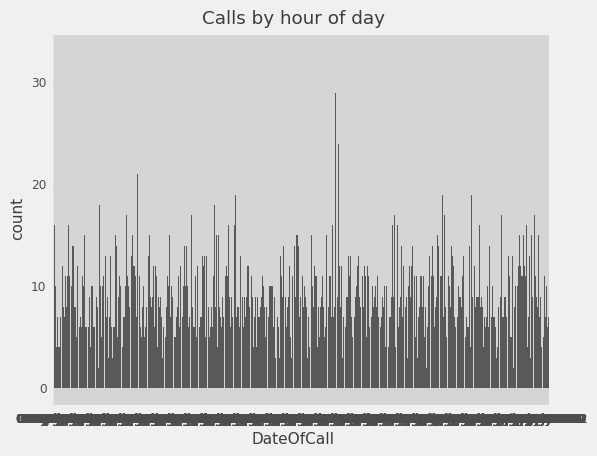

<ggplot: (108898927351)>

In [ ]:
(ggplot(data=new_df) + aes(x='DateOfCall',group=1) + geom_bar() + ggtitle(title='Calls by hour of day')
 + theme_538())

# average first response time

In [ ]:
new_df.head()

,level_0,index,IncidentNumber,DateOfCall,CalYear,TimeOfCall,HourOfCall,IncidentGroup,StopCodeDescription,SpecialServiceType,...,FirstPumpArriving_AttendanceTime,FirstPumpArriving_DeployedFromStation,SecondPumpArriving_AttendanceTime,SecondPumpArriving_DeployedFromStation,NumStationsWithPumpsAttending,NumPumpsAttending,PumpCount,PumpHoursRoundUp,Notional Cost (£),NumCalls
0,0,758,001466-03012019,03 Jan 2019,2019,22:47:34,22,Special Service,Special Service,RTC,...,362.0,Ruislip,721.0,Northolt,2.0,2.0,5.0,3.0,999.0,2.0
1,1,1684,003039-07012019,07 Jan 2019,2019,20:21:50,20,Special Service,Special Service,RTC,...,425.0,Ruislip,551.0,Harrow,2.0,2.0,2.0,1.0,333.0,1.0
2,2,3048,005261-13012019,13 Jan 2019,2019,15:18:08,15,Special Service,Special Service,Other Transport incident,...,132.0,Heathrow,303.0,Hayes,3.0,3.0,3.0,1.0,333.0,1.0
3,3,3529,005985-15012019,15 Jan 2019,2019,16:06:48,16,Special Service,Special Service,Suicide/attempts,...,368.0,Hayes,394.0,Hillingdon,2.0,2.0,2.0,2.0,666.0,1.0
4,4,3970,006720-17012019,17 Jan 2019,2019,10:06:37,10,Special Service,Special Service,Stand By,...,334.0,Feltham,350.0,Feltham,2.0,3.0,3.0,2.0,666.0,1.0


In [ ]:
plt.figure(figsize=[4,4],)
plt.title('Average First Response Time (hour) by HourOfCall')
sns.swarmplot(data=new_df,x='HourOfCall', y='DateOfCall')

<AxesSubplot:title={'center':'Average First Response Time (hour) by HourOfCall'}, xlabel='HourOfCall', ylabel='DateOfCall'>

In [ ]:
plt.figure(figsize=[7,7],)
plt.title('Average First Response Time (hour) by Hour of Call')
sns.boxplot(data=new_df,x='HourOfCall', y='DateOfCall')
plt.plot([-1,24],[6, 6], linewidth=3,linestyle='dashed', )

In [ ]:
plt.figure(figsize=[7,7],)
plt.title('Average Second Response Time (hours) by Hour of Call')
sns.boxplot(data=new_df,x='HourOfCall', y='DateOfCall')
plt.plot([-1,24],[8, 8], linewidth=3,linestyle='dashed', )

In [ ]:
pd.options.display.max_columns = 999
from plotnine import *
import re
import matplotlib
import matplotlib.pyplot as plt
plt.style.use('ggplot')
%matplotlib inline

# Different Types of Incidents

<AxesSubplot:title={'center':'SpecialServiceType'}, ylabel='StopCodeDescription'>

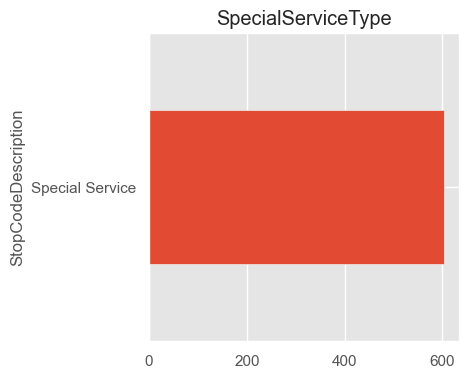

In [ ]:
new_df.groupby(['StopCodeDescription']).size().sort_values().plot(kind='barh', figsize=[4,4], title='SpecialServiceType')

TypeError: Could not convert RTCRTCOther Transport incidentSuicide/attemptsStand ByOther Transport incidentRTCRTCRTCRTCRTCRTCRTCRTCRemoval of objects from peopleRTCRTCRTCRTCRTCRTCOther Transport incidentStand ByMaking Safe (not RTC)RTCRTCRTCRTCRTCOther Transport incidentRTCRTCEvacuation (no fire)RTCRTCStand BySuicide/attemptsOther Transport incidentRTCAssist other agenciesOther Transport incidentRTCRTCRTCRTCRTCRTCRTCRTCRTCRTCRTCRTCOther Transport incidentAssist other agenciesRTCRTCRTCRTCRTCRTCMedical IncidentOther Transport incidentRTCNo action (not false alarm)RTCRTCOther Transport incidentRTCOther Transport incidentOther rescue/release of personsHazardous Materials incidentRTCRTCRTCOther Transport incidentAssist other agenciesRTCRTCRTCRTCRTCRTCRTCOther Transport incidentStand ByStand ByRTCRTCRTCSpills and Leaks (not RTC)Other Transport incidentRTCRTCRTCRTCRTCRTCHazardous Materials incidentRTCRTCRTCRTCRTCRTCHazardous Materials incidentHazardous Materials incidentAdvice OnlyStand ByNo 

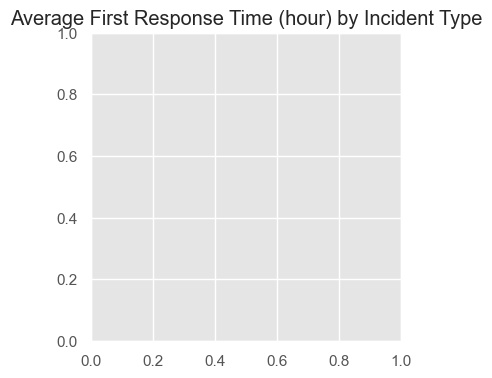

In [ ]:
plt.figure(figsize=[4,4],)
plt.title('Average First Response Time (hour) by Incident Type')

ranks = new_df.groupby("StopCodeDescription")["SpecialServiceType"].mean().fillna(0).sort_values()[::-1].index
sns.boxplot(data=new_df, y='StopCodeDescription', x='SpecialServiceType', orient='h', order=ranks)


Multiple Vehicles 


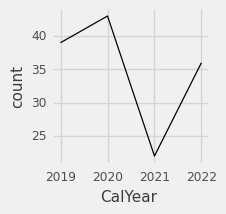



Passenger plane 


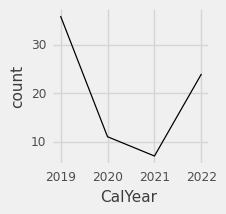



Barge 


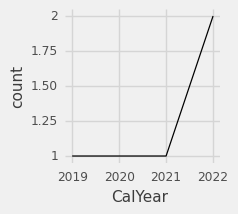



Car 


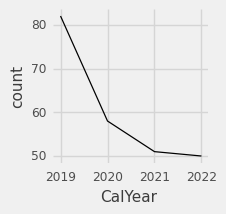



Large supermarket 


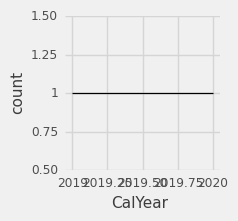



Other outdoor structures 


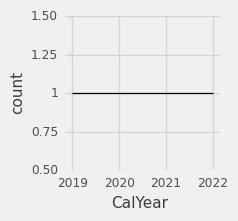



Purpose built office 


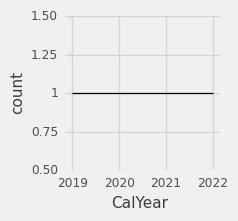



Road surface/pavement 


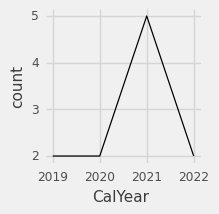



Van 


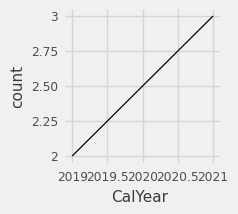



Other outdoor location 


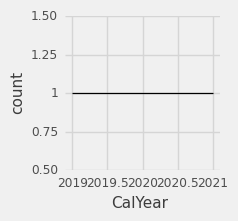



Train on Tube network


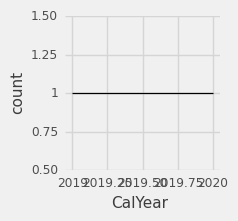



Train station - concourse 


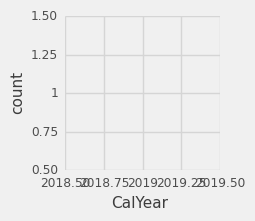



Warehouse 


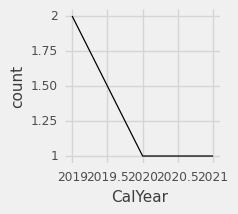



Bus/coach 


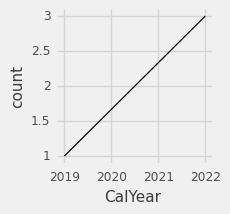



Motorcycle 


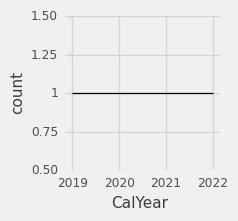



Other road vehicle


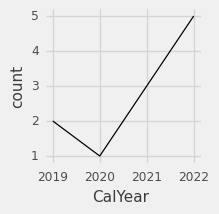



College/University 


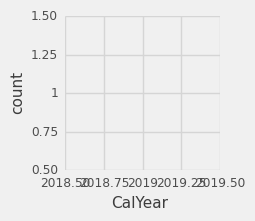



Lorry/HGV 


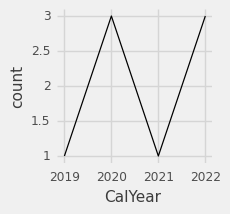



Hospital 


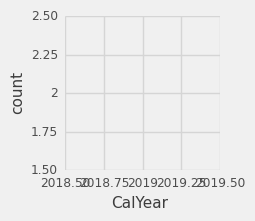



Petrol station 


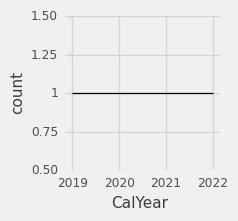



Other bulk storage


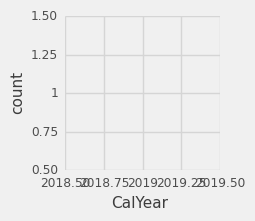



Airport building (not terminal or hangar) 


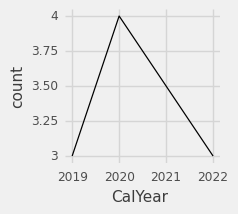



Multi-Storey car park


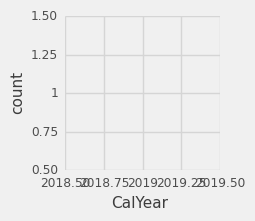



Church/Chapel 


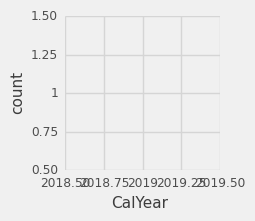



River/canal 


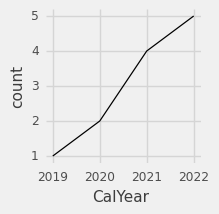



Pub/wine bar/bar 


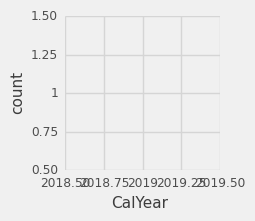



Lake/pond/reservoir 


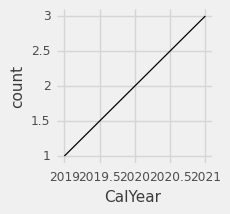



Airport - terminal 


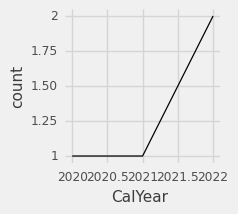



Single shop 


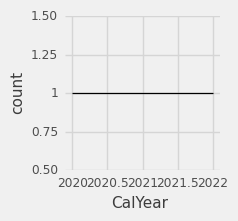



Airfield/runway 


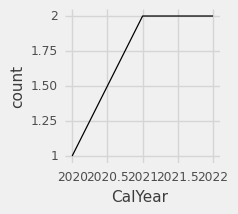



Hotel/motel 


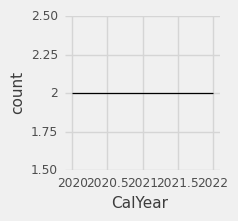



Passenger Train (national rail network) 


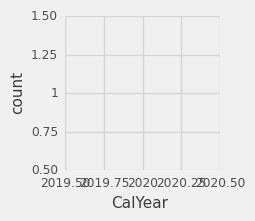



Bridge


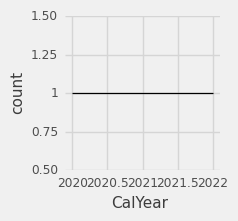



Playground/Recreation area (not equipment)


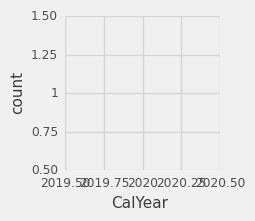



Bicycle


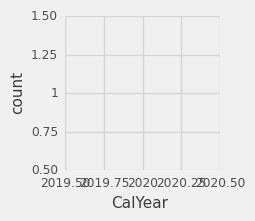



Train station - elsewhere 


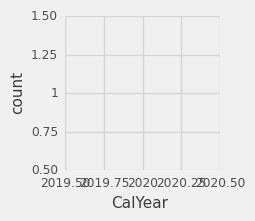



Shopping Centre 


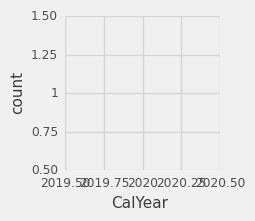



Freight plane 


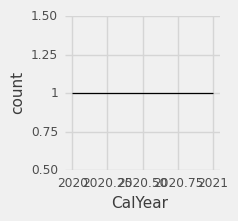



Outdoor storage 


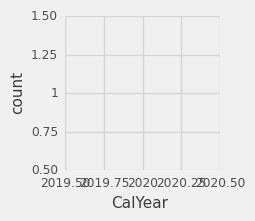



Heathland 


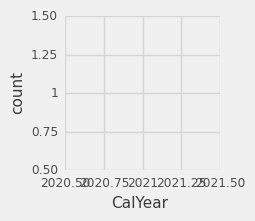



Other vessel 


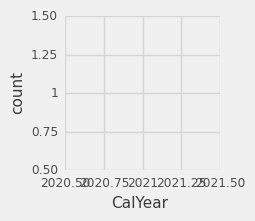



Human harm outdoors


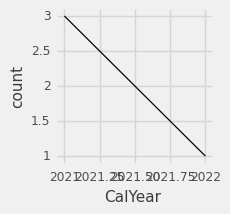



Retirement/Old Persons Home


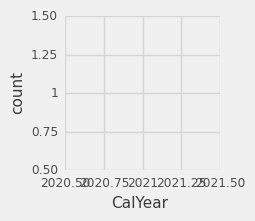



Park 


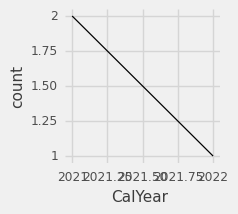



Fence


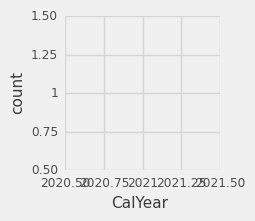



Golf course (not building on course)


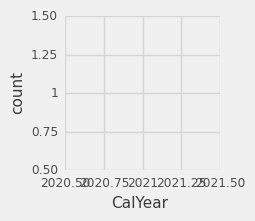



Canal/riverbank vegetation 


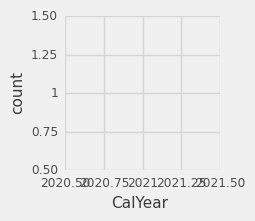



Minibus 


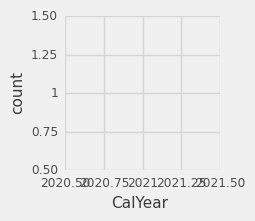



Train station - platform (at ground level or elevated) 


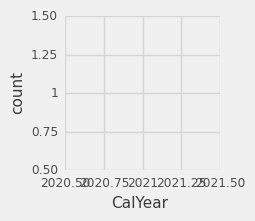



Agricultural vehicle


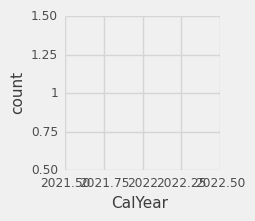



Other outdoor equipment/machinery 


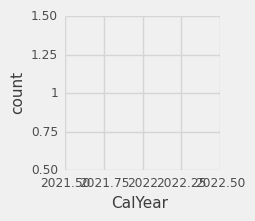



Scrub land 


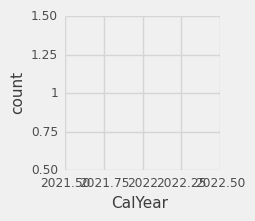



Leisure Centre 


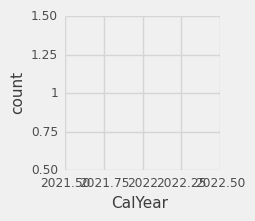



Food and drink processing


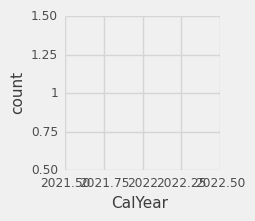



Secondary school


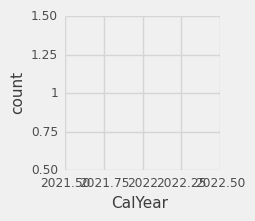



Tunnel/ subway 


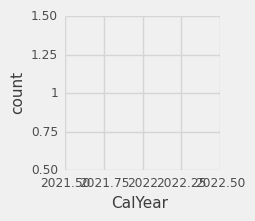



Electricity power station 


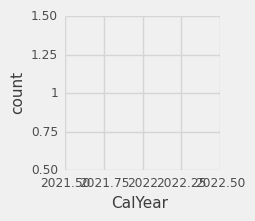

In [ ]:
hillingdon= new_df.PropertyType.unique()

for i in hillingdon:
    print ("")
    print (i)
    print((ggplot(new_df[new_df['PropertyType']==i]) +
 aes(x= 'CalYear', group=1) + stat_count(geom='line', ) +theme_538() +theme(figure_size=[2,2])))

In [ ]:
new_df[int_li].corr() #find the pairwise correlation of all columns in the Pandas Dataframe

,level_0,index,CalYear,HourOfCall,UPRN,USRN,Easting_rounded,Northing_rounded
level_0,1.000000,0.995200,0.964229,-0.071816,-0.024513,0.013090,-0.058391,-0.079871
index,0.995200,1.000000,0.970700,-0.067988,-0.030953,0.020522,-0.062405,-0.079531
CalYear,0.964229,0.970700,1.000000,-0.056653,-0.034131,0.043108,-0.046123,-0.075632
HourOfCall,-0.071816,-0.067988,-0.056653,1.000000,0.011682,0.051275,0.031165,0.005069
UPRN,-0.024513,-0.030953,-0.034131,0.011682,1.000000,-0.173123,0.191491,0.375130
USRN,0.013090,0.020522,0.043108,0.051275,-0.173123,1.000000,-0.122939,-0.173623
Easting_rounded,-0.058391,-0.062405,-0.046123,0.031165,0.191491,-0.122939,1.000000,0.314384
Northing_rounded,-0.079871,-0.079531,-0.075632,0.005069,0.375130,-0.173623,0.314384,1.000000


In [ ]:
df.cov()

,CalYear,HourOfCall,UPRN,USRN,Easting_m,Northing_m,Easting_rounded,Northing_rounded,Latitude,Longitude,FirstPumpArriving_AttendanceTime,SecondPumpArriving_AttendanceTime,NumStationsWithPumpsAttending,NumPumpsAttending,PumpCount,PumpHoursRoundUp,Notional Cost (£),NumCalls
CalYear,1.272081e+00,-6.292975e-02,-1.689959e+09,6.743010e+04,1.113586e+02,-1.147085e+01,2.401181e+01,-7.976373e+00,-3.487947e-02,1.768432e-03,2.718107e+00,5.521058e+00,9.804486e-03,-2.721074e-02,-2.685113e-02,1.689905e-03,1.416120e+01,8.812752e-03
HourOfCall,-6.292975e-02,3.940453e+01,-3.587738e+09,5.593690e+05,1.006273e+03,-2.576980e+02,3.916749e+02,-6.461360e+01,4.455208e-02,1.416742e-02,-2.671634e+01,-1.778790e+01,8.877182e-02,7.373888e-02,3.088463e-02,-1.098785e-01,-3.770661e+01,8.819898e-02
UPRN,-1.689959e+09,-3.587738e+09,2.074190e+21,-1.291725e+16,5.810003e+13,-6.843715e+13,2.673580e+13,-3.405378e+13,5.096321e+08,8.016502e+08,-5.920961e+09,5.887174e+10,-3.199214e+09,-4.249149e+09,-4.164269e+09,-7.540625e+08,-2.790718e+11,2.135715e+09
USRN,6.743010e+04,5.593690e+05,-1.291725e+16,2.100778e+13,5.670470e+08,-6.105908e+06,1.964761e+09,-8.808285e+08,-9.750139e+04,8.643276e+03,2.491788e+07,6.757321e+07,1.632524e+05,5.725706e+04,7.378583e+04,1.707432e+05,6.069829e+07,2.115868e+05
Easting_m,1.113586e+02,1.006273e+03,5.810003e+13,5.670470e+08,1.099148e+08,4.822708e+06,1.099153e+08,4.818685e+06,5.062288e+02,1.576940e+03,-4.338973e+04,-4.863466e+04,1.916759e+01,-8.085105e+01,1.083868e+02,7.200997e+02,2.542886e+05,4.246507e+02
Northing_m,-1.147085e+01,-2.576980e+02,-6.843715e+13,-6.105908e+06,4.822708e+06,5.697335e+07,4.821472e+06,5.697187e+07,6.395477e+02,8.944558e+01,3.447575e+04,4.631563e+04,2.770756e+01,6.292706e+01,1.355579e+02,3.305856e+02,1.172180e+05,2.459698e+02
Easting_rounded,2.401181e+01,3.916749e+02,2.673580e+13,1.964761e+09,1.099153e+08,4.821472e+06,9.529371e+07,3.467011e+06,5.058083e+02,1.576949e+03,-3.020229e+04,-3.871625e+04,7.237077e+01,-8.107189e+01,-4.531240e+00,3.455306e+02,1.223545e+05,2.318914e+02
Northing_rounded,-7.976373e+00,-6.461360e+01,-3.405378e+13,-8.808285e+08,4.818685e+06,5.697187e+07,3.467011e+06,5.545201e+07,6.393621e+02,8.938915e+01,3.552206e+04,3.066618e+04,-6.037550e+01,-4.172816e+00,1.330263e+01,1.011254e+02,3.629651e+04,1.164518e+02
Latitude,-3.487947e-02,4.455208e-02,5.096321e+08,-9.750139e+04,5.062288e+02,6.395477e+02,5.058083e+02,6.393621e+02,7.857166e+00,-1.757062e-02,9.327629e+00,1.988876e+00,-1.158602e-02,-1.191559e-02,-8.980507e-03,1.272642e-02,4.220411e+00,4.566616e-02
Longitude,1.768432e-03,1.416742e-02,8.016502e+08,8.643276e+03,1.576940e+03,8.944558e+01,1.576949e+03,8.938915e+01,-1.757062e-02,2.280237e-02,-6.118506e-01,-6.574217e-01,3.379444e-04,-1.088623e-03,1.652826e-03,1.044891e-02,3.691542e+00,6.064586e-03


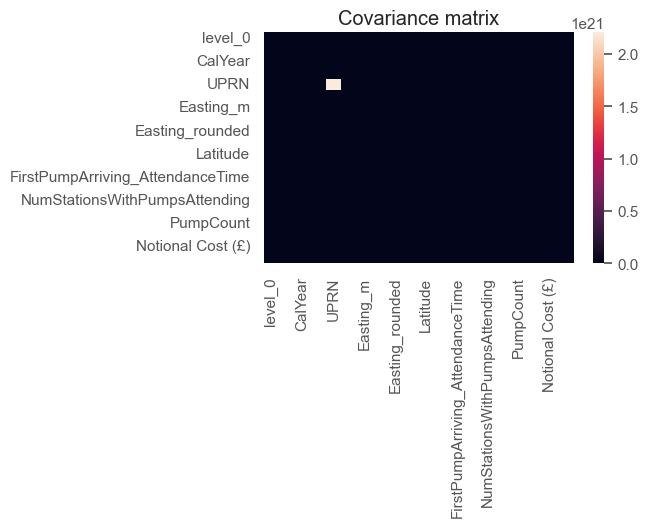

In [ ]:
plt.figure(figsize=(5,3))
sns.heatmap(new_df.cov())
plt.title('Covariance matrix')
plt.show()

In [ ]:
new_df[int_li].corr(method='pearson')

,level_0,index,CalYear,HourOfCall,UPRN,USRN,Easting_rounded,Northing_rounded
level_0,1.000000,0.995200,0.964229,-0.071816,-0.024513,0.013090,-0.058391,-0.079871
index,0.995200,1.000000,0.970700,-0.067988,-0.030953,0.020522,-0.062405,-0.079531
CalYear,0.964229,0.970700,1.000000,-0.056653,-0.034131,0.043108,-0.046123,-0.075632
HourOfCall,-0.071816,-0.067988,-0.056653,1.000000,0.011682,0.051275,0.031165,0.005069
UPRN,-0.024513,-0.030953,-0.034131,0.011682,1.000000,-0.173123,0.191491,0.375130
USRN,0.013090,0.020522,0.043108,0.051275,-0.173123,1.000000,-0.122939,-0.173623
Easting_rounded,-0.058391,-0.062405,-0.046123,0.031165,0.191491,-0.122939,1.000000,0.314384
Northing_rounded,-0.079871,-0.079531,-0.075632,0.005069,0.375130,-0.173623,0.314384,1.000000


<AxesSubplot:>

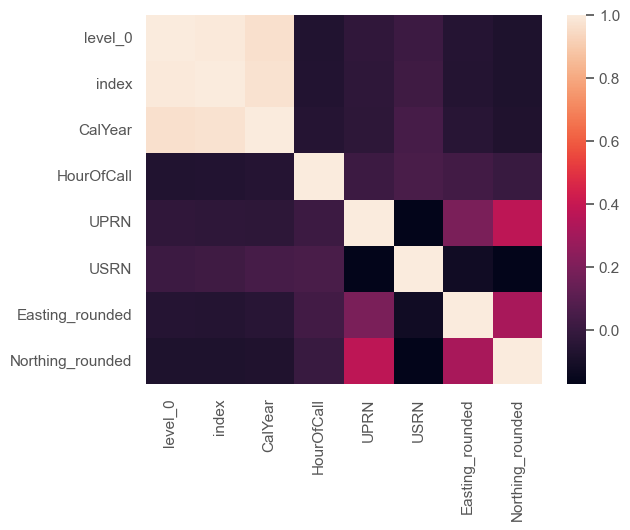

In [ ]:
import seaborn as sn
sn.heatmap(new_df[int_li].corr(method='pearson')) #heat map

In [ ]:
df=df.drop(['CalYear','HourOfCall','IncidentGroup','SpecialServiceType'],axis=1)

In [ ]:
new_df.head(1)

,level_0,index,IncidentNumber,DateOfCall,CalYear,TimeOfCall,HourOfCall,IncidentGroup,StopCodeDescription,SpecialServiceType,PropertyCategory,PropertyType,AddressQualifier,Postcode_full,Postcode_district,UPRN,USRN,IncGeo_BoroughCode,IncGeo_BoroughName,ProperCase,IncGeo_WardCode,IncGeo_WardName,IncGeo_WardNameNew,Easting_m,Northing_m,Easting_rounded,Northing_rounded,Latitude,Longitude,FRS,IncidentStationGround,FirstPumpArriving_AttendanceTime,FirstPumpArriving_DeployedFromStation,SecondPumpArriving_AttendanceTime,SecondPumpArriving_DeployedFromStation,NumStationsWithPumpsAttending,NumPumpsAttending,PumpCount,PumpHoursRoundUp,Notional Cost (£),NumCalls
0,0,758,001466-03012019,03 Jan 2019,2019,22:47:34,22,Special Service,Special Service,RTC,Road Vehicle,Multiple Vehicles,In street outside gazetteer location,HA6 1HF,HA6,100023661471,21401951,E09000017,HILLINGDON,Hillingdon,E05013574,Northwood,Northwood,509488.0,190806.0,509450,190850,51.605463,-0.420375,London,Ruislip,362.0,Ruislip,721.0,Northolt,2.0,2.0,5.0,3.0,999.0,2.0


In [ ]:
int_li

['level_0',
 'index',
 'CalYear',
 'HourOfCall',
 'UPRN',
 'USRN',
 'Easting_rounded',
 'Northing_rounded']

In [ ]:
int_li=['CalYear','HourOfCall','USRN','Easting_rounded']

<AxesSubplot:>

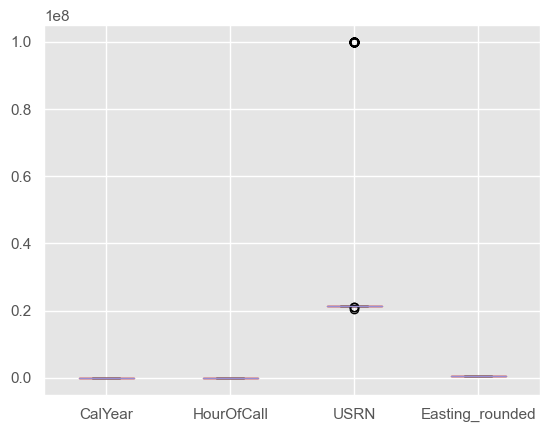

In [ ]:
# Creating plot
# plt.boxplot(df[obj_li])

# fig = plt.figure(figsize =(10, 7))
# # show plot
# plt.show()
new_df[int_li].boxplot()

In [ ]:
for i in obj_li:
    print(new_df[i].unique()) #when we deal with a single column of a DataFrame and returns all unique elements of a column

['001466-03012019' '003039-07012019' '005261-13012019' '005985-15012019'
 '006720-17012019' '007190-18012019' '007352-18012019' '007798-19012019'
 '007886-19012019' '008075-20012019' '008250-20012019' '008973-22012019'
 '009611-24012019' '010395-25012019' '010703-26012019' '011873-29012019'
 '012610-31012019' '013390-02022019' '013705-02022019' '014923-05022019'
 '015535-06022019' '016239-08022019' '016855-09022019' '016954-10022019'
 '017502-11022019' '019030-15022019' '019397-16022019' '020902-19022019'
 '021198-20022019' '023062-24022019' '024253-27022019' '026045-03032019'
 '026745-05032019' '030101-12032019' '031603-16032019' '032225-17032019'
 '033071-19032019' '034395-22032019' '034422-22032019' '034482-22032019'
 '034835-23032019' '035682-25032019' '035930-25032019' '037870-29032019'
 '040256-04042019' '041287-06042019' '041324-07042019' '042868-10042019'
 '043635-12042019' '044817-15042019' '046948-19042019' '049785-24042019'
 '052448-30042019' '052996-01052019' '053673-020520

In [ ]:
new_df.head() #get the first n rows

,level_0,index,IncidentNumber,DateOfCall,CalYear,TimeOfCall,HourOfCall,IncidentGroup,StopCodeDescription,SpecialServiceType,PropertyCategory,PropertyType,AddressQualifier,Postcode_full,Postcode_district,UPRN,USRN,IncGeo_BoroughCode,IncGeo_BoroughName,ProperCase,IncGeo_WardCode,IncGeo_WardName,IncGeo_WardNameNew,Easting_m,Northing_m,Easting_rounded,Northing_rounded,Latitude,Longitude,FRS,IncidentStationGround,FirstPumpArriving_AttendanceTime,FirstPumpArriving_DeployedFromStation,SecondPumpArriving_AttendanceTime,SecondPumpArriving_DeployedFromStation,NumStationsWithPumpsAttending,NumPumpsAttending,PumpCount,PumpHoursRoundUp,Notional Cost (£),NumCalls
0,0,758,001466-03012019,03 Jan 2019,2019,22:47:34,22,Special Service,Special Service,RTC,Road Vehicle,Multiple Vehicles,In street outside gazetteer location,HA6 1HF,HA6,100023661471,21401951,E09000017,HILLINGDON,Hillingdon,E05013574,Northwood,Northwood,509488.0,190806.0,509450,190850,51.605463,-0.420375,London,Ruislip,362.0,Ruislip,721.0,Northolt,2.0,2.0,5.0,3.0,999.0,2.0
1,1,1684,003039-07012019,07 Jan 2019,2019,20:21:50,20,Special Service,Special Service,RTC,Road Vehicle,Multiple Vehicles,In street outside gazetteer location,HA6 1NL,HA6,100023661139,21401058,E09000017,HILLINGDON,Hillingdon,E05013575,Northwood Hills,Northwood Hills,510212.0,189937.0,510250,189950,51.597515,-0.410185,London,Ruislip,425.0,Ruislip,551.0,Harrow,2.0,2.0,2.0,1.0,333.0,1.0
2,2,3048,005261-13012019,13 Jan 2019,2019,15:18:08,15,Special Service,Special Service,Other Transport incident,Aircraft,Passenger plane,In street outside gazetteer location,TW6 2AQ,TW6,768011491,21401419,E09000017,HILLINGDON,Hillingdon,E05013570,Heathrow Villages,Heathrow Villages,507702.0,176712.0,507750,176750,51.479132,-0.450452,London,Heathrow,132.0,Heathrow,303.0,Hayes,3.0,3.0,3.0,1.0,333.0,1.0
3,3,3529,005985-15012019,15 Jan 2019,2019,16:06:48,16,Special Service,Special Service,Suicide/attempts,Boat,Barge,Open land/water - nearest gazetteer location,UB7 8JR,UB7,10092980270,21401016,E09000017,HILLINGDON,Hillingdon,E05013584,Yiewsley,Yiewsley,506608.0,180080.0,506650,180050,51.509605,-0.465186,London,Hillingdon,368.0,Hayes,394.0,Hillingdon,2.0,2.0,2.0,2.0,666.0,1.0
4,4,3970,006720-17012019,17 Jan 2019,2019,10:06:37,10,Special Service,Special Service,Stand By,Aircraft,Passenger plane,On land associated with building,TW6 1DB,TW6,10090329613,21402329,E09000017,HILLINGDON,Hillingdon,E05013570,Heathrow Villages,Heathrow Villages,507533.0,175857.0,507550,175850,51.471479,-0.453153,London,Heathrow,334.0,Feltham,350.0,Feltham,2.0,3.0,3.0,2.0,666.0,1.0


# Frequency Distribution

array([[<AxesSubplot:title={'center':'CalYear'}>,
        <AxesSubplot:title={'center':'HourOfCall'}>],
       [<AxesSubplot:title={'center':'USRN'}>,
        <AxesSubplot:title={'center':'Easting_rounded'}>]], dtype=object)

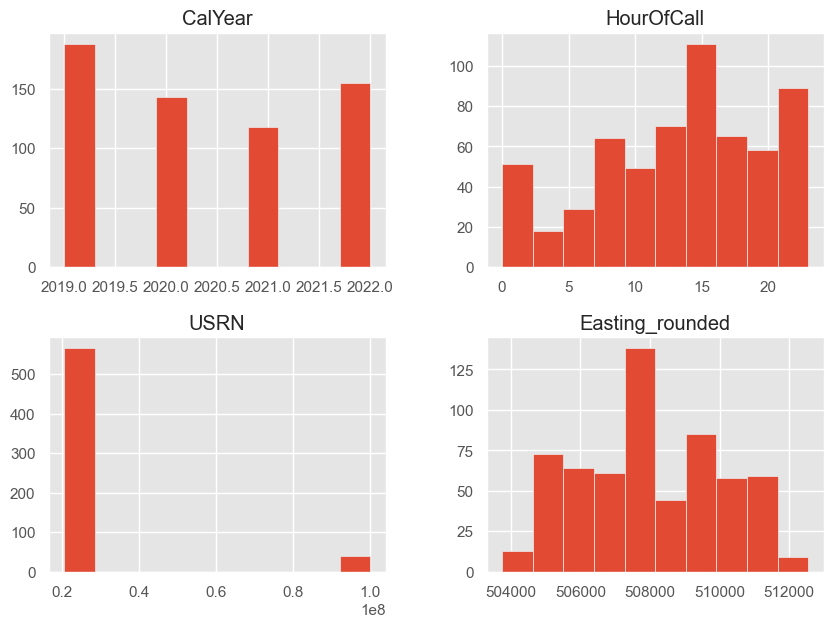

In [ ]:
new_df[int_li].hist(figsize=(10,7)) # draw histogram

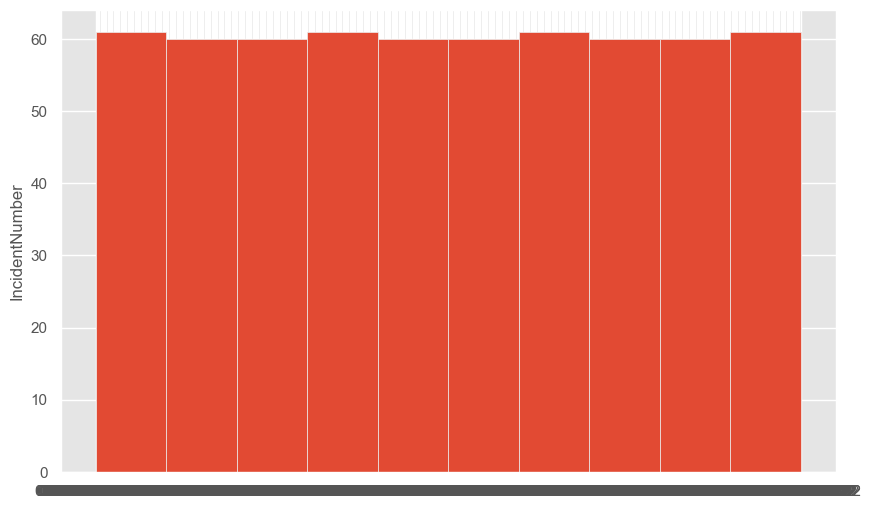

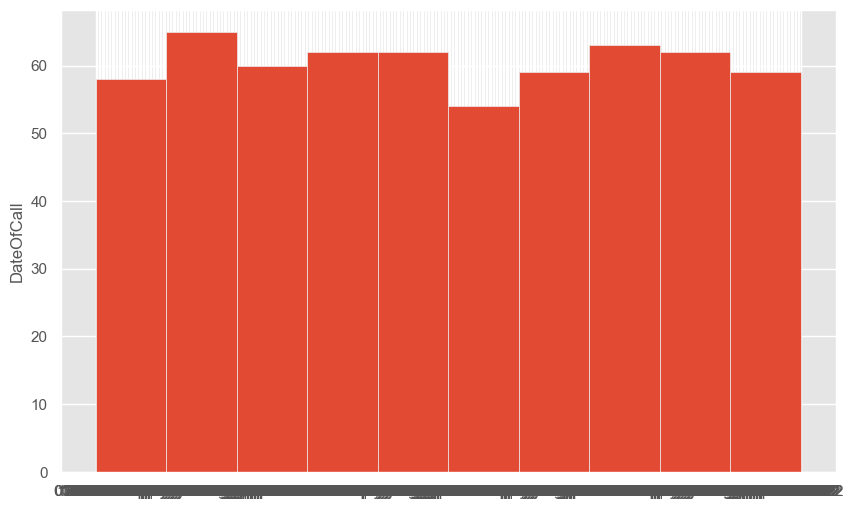

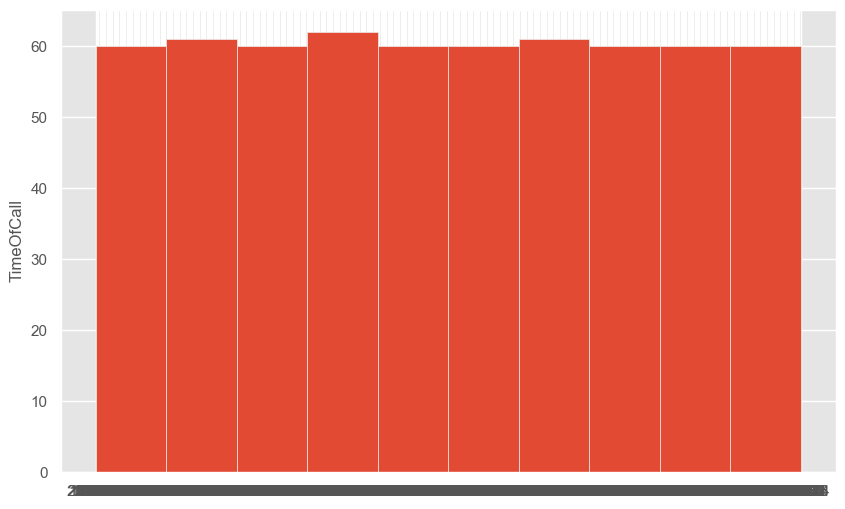

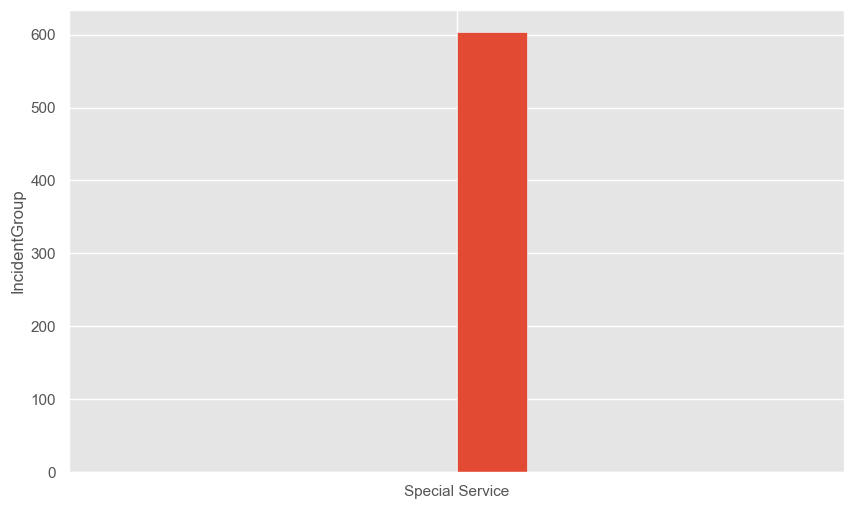

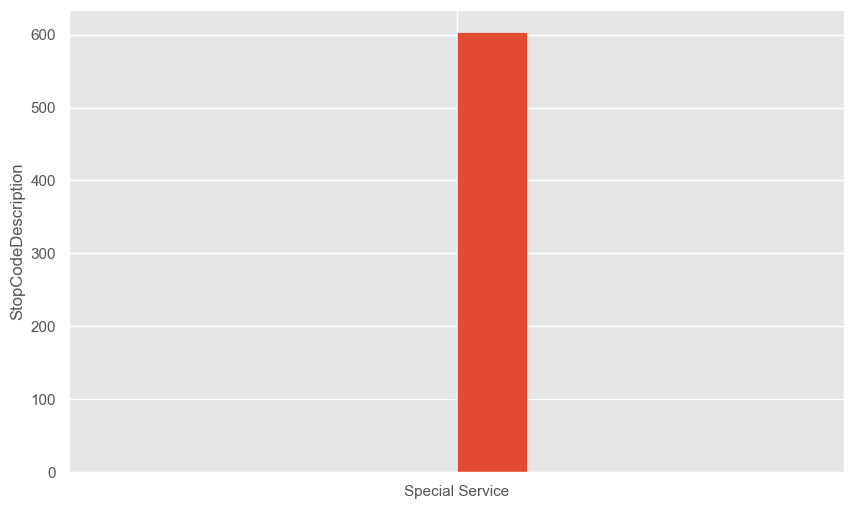

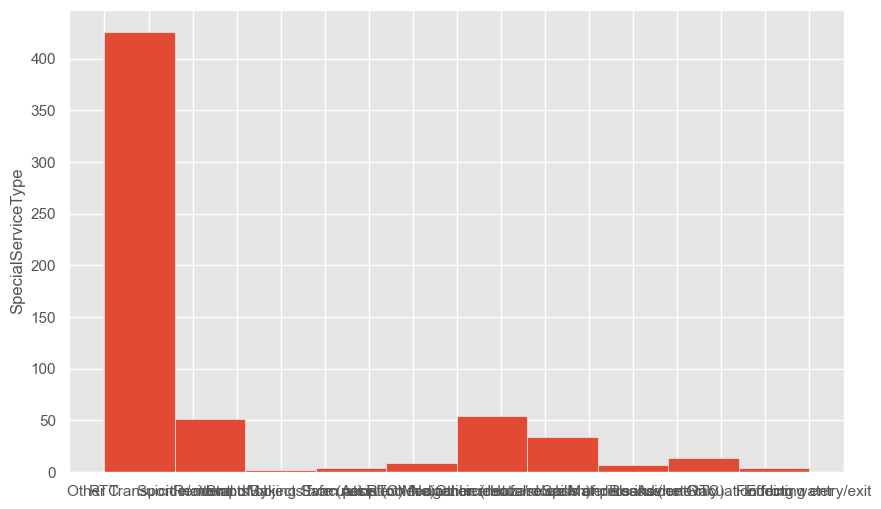

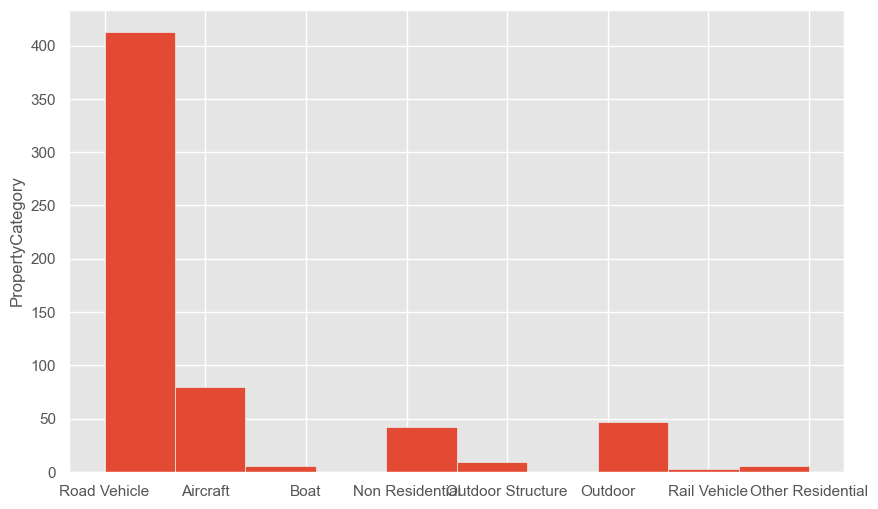

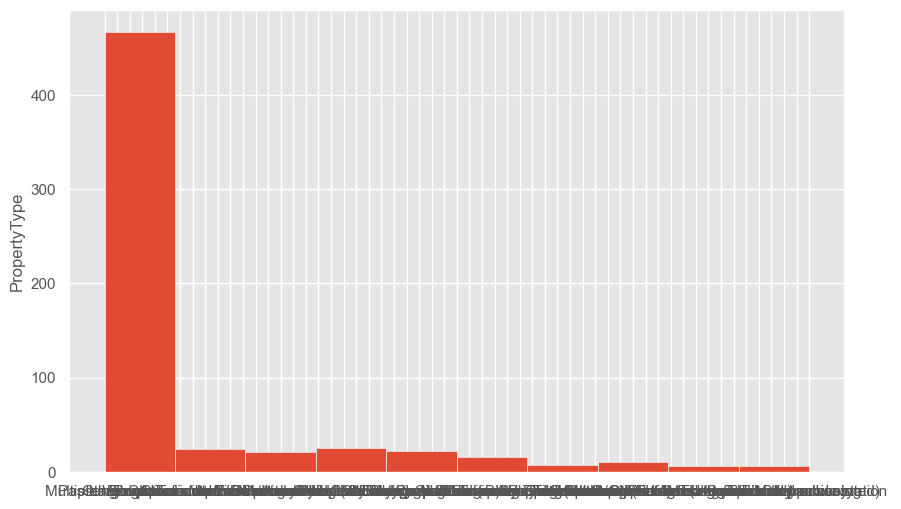

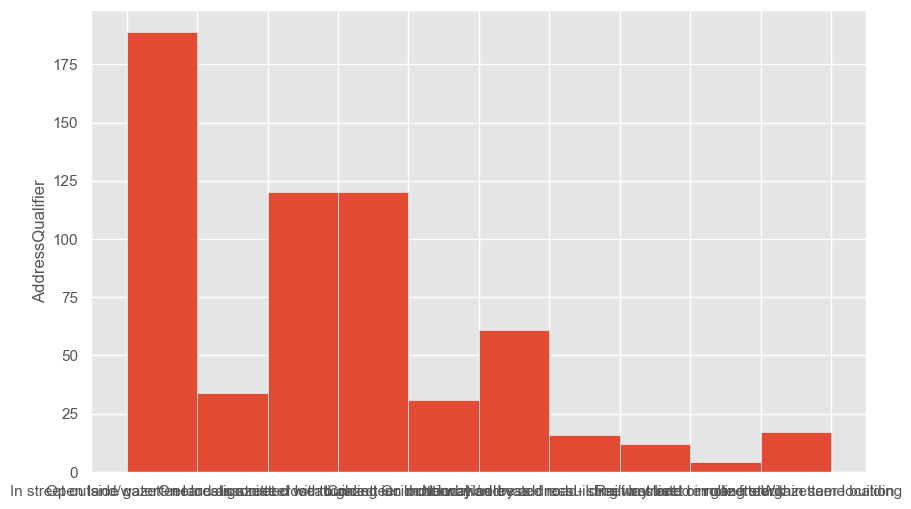

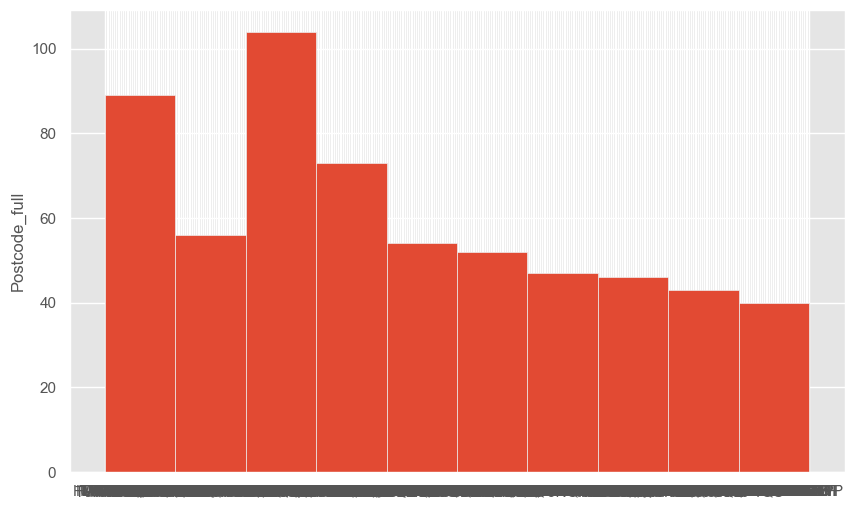

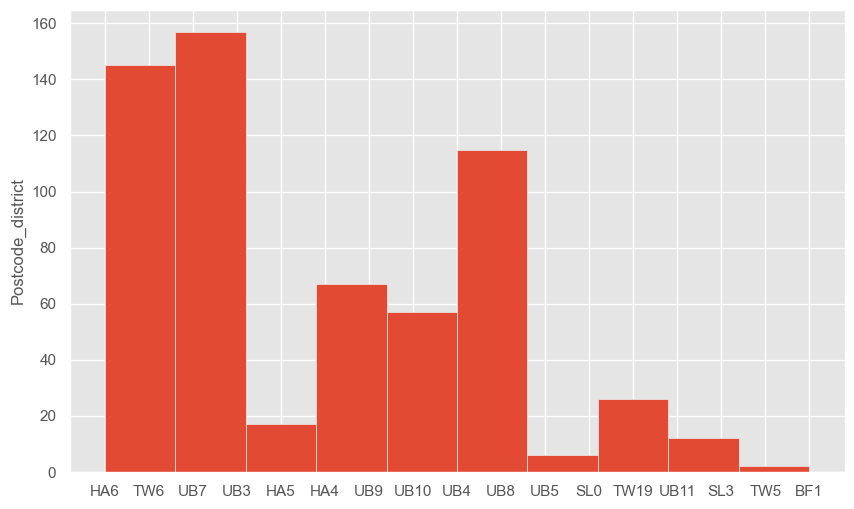

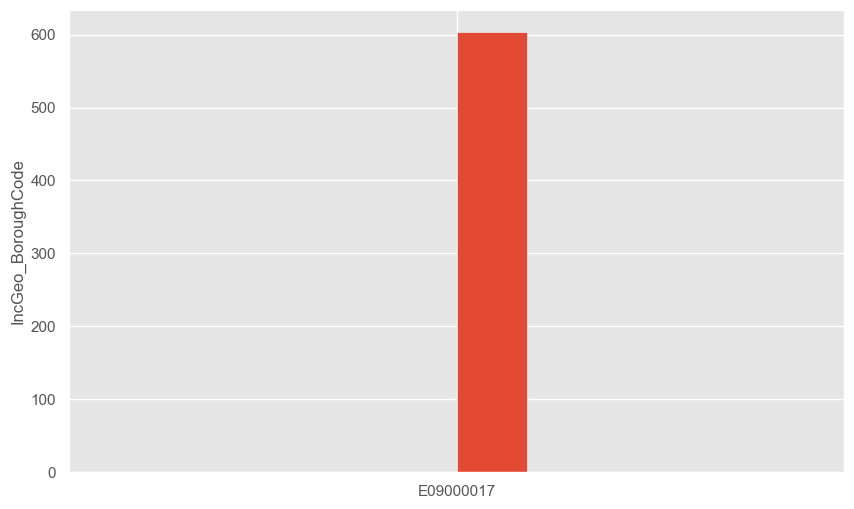

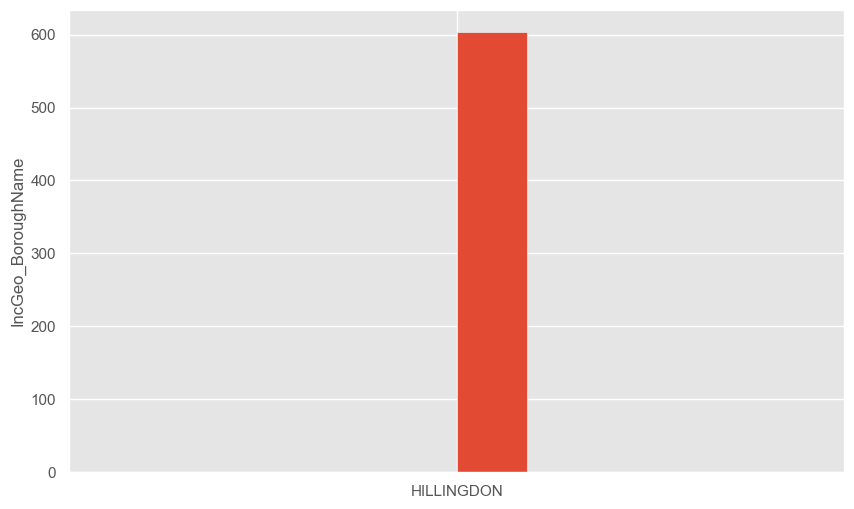

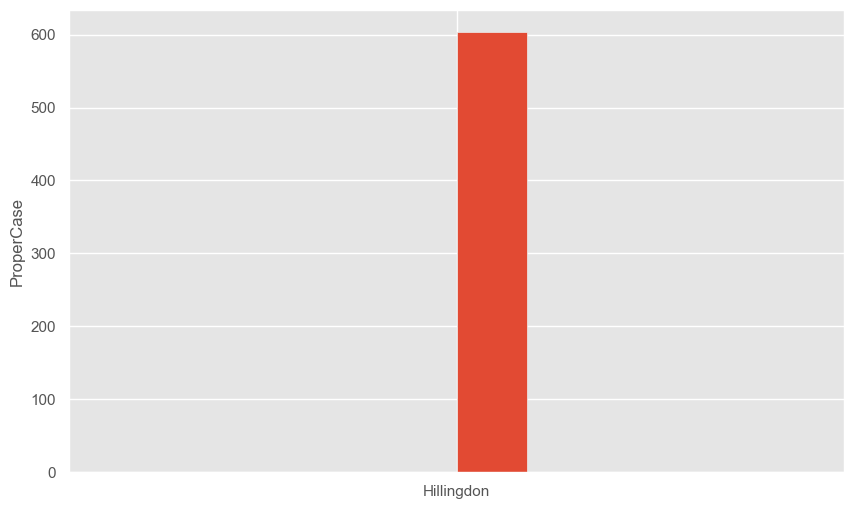

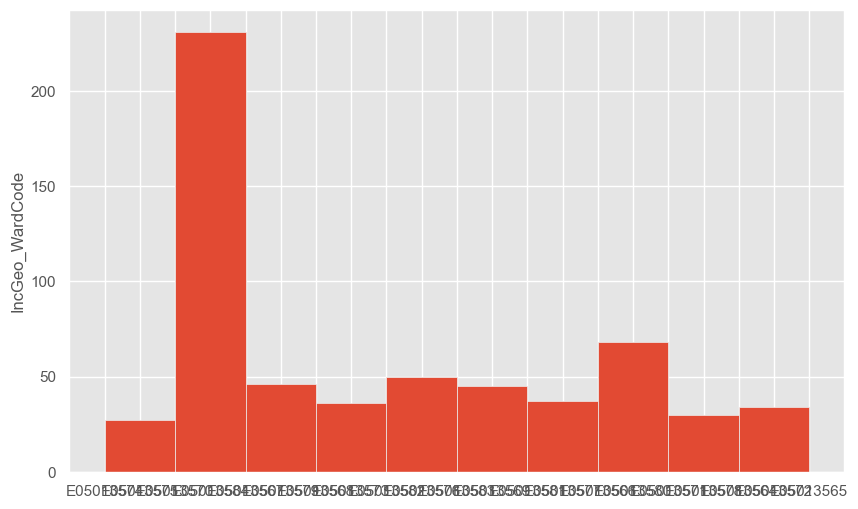

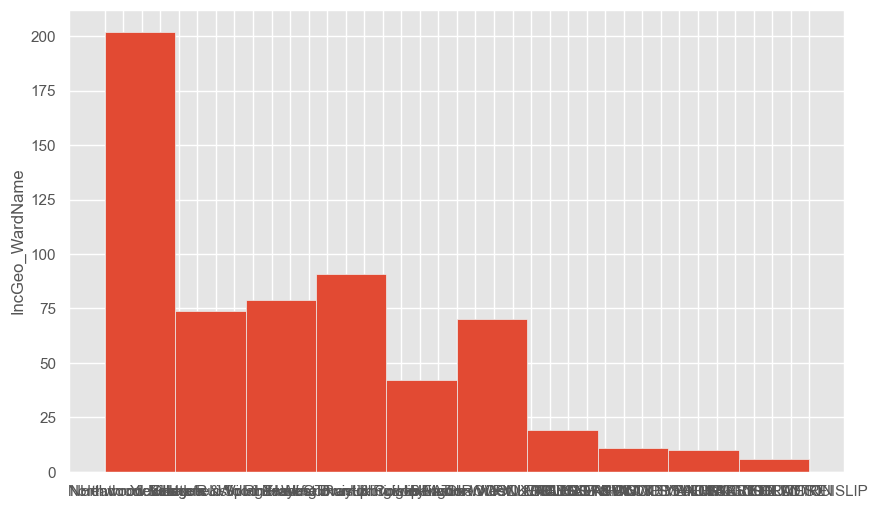

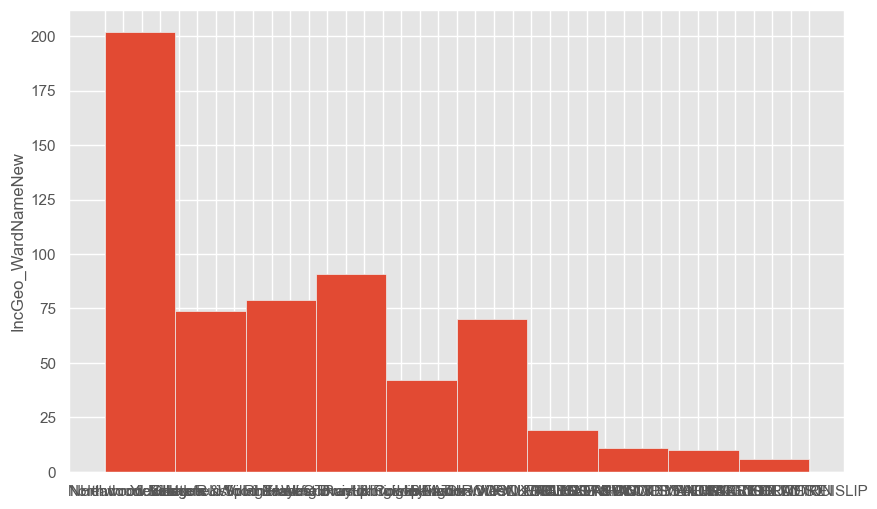

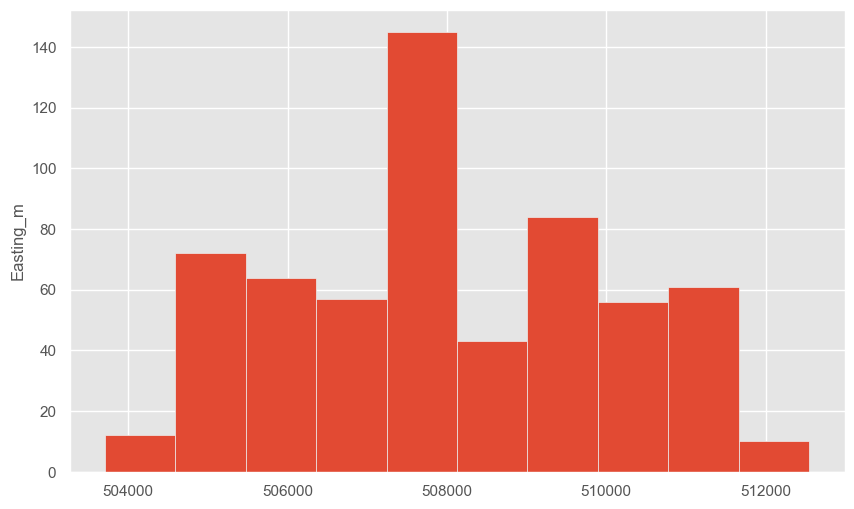

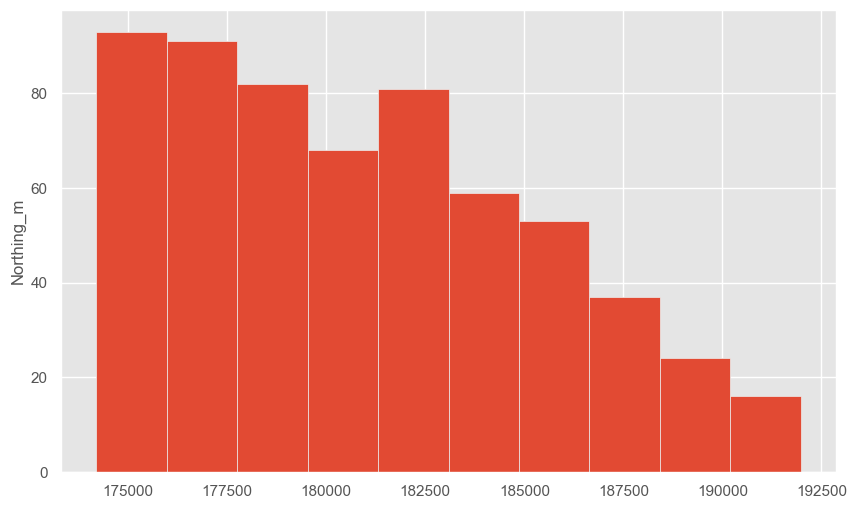

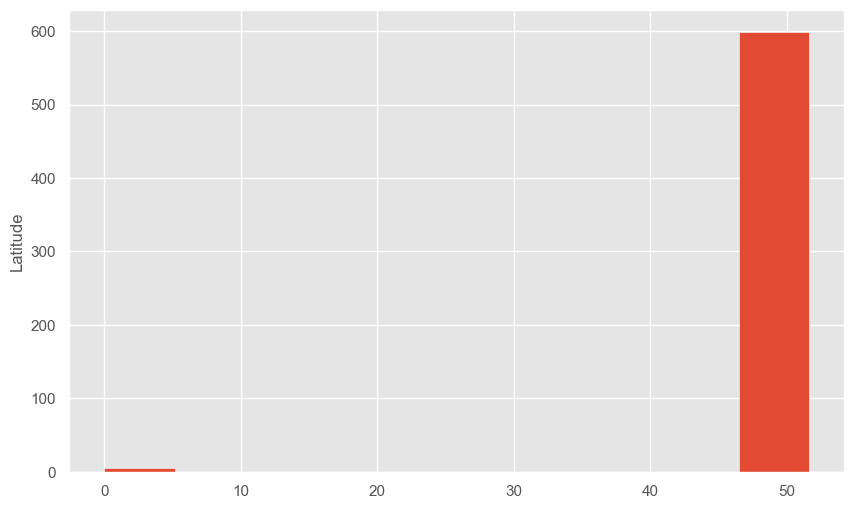

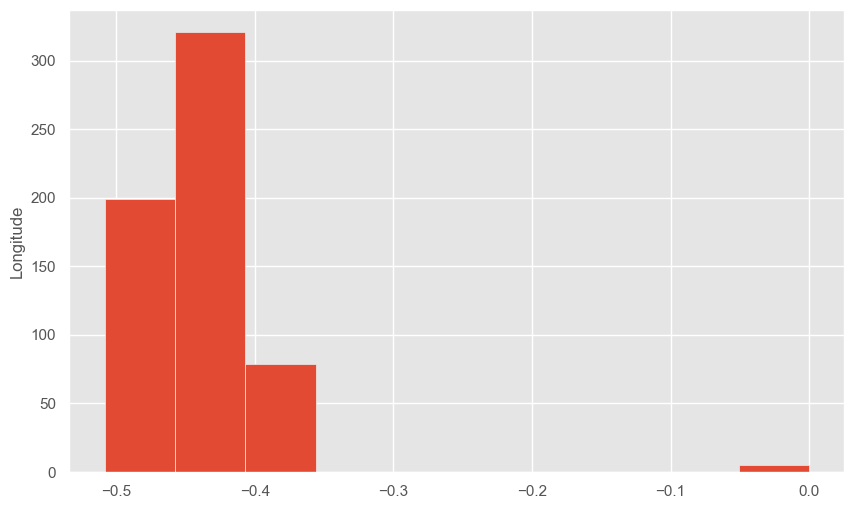

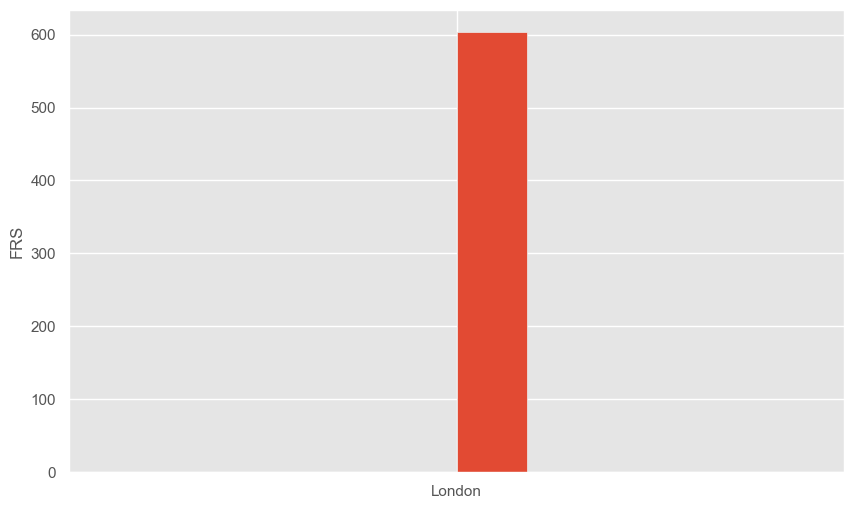

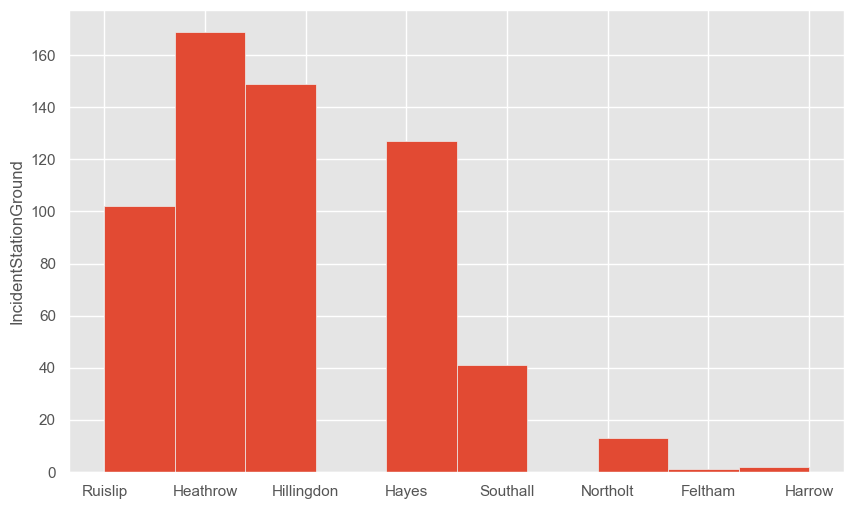

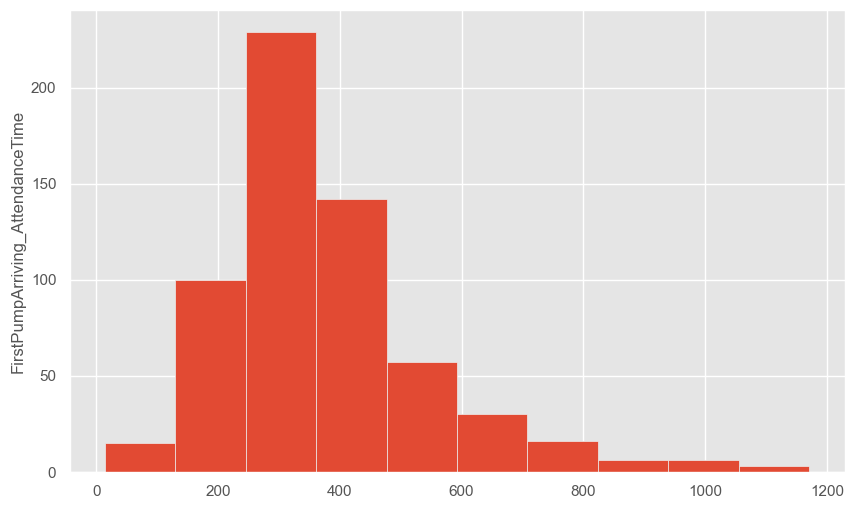

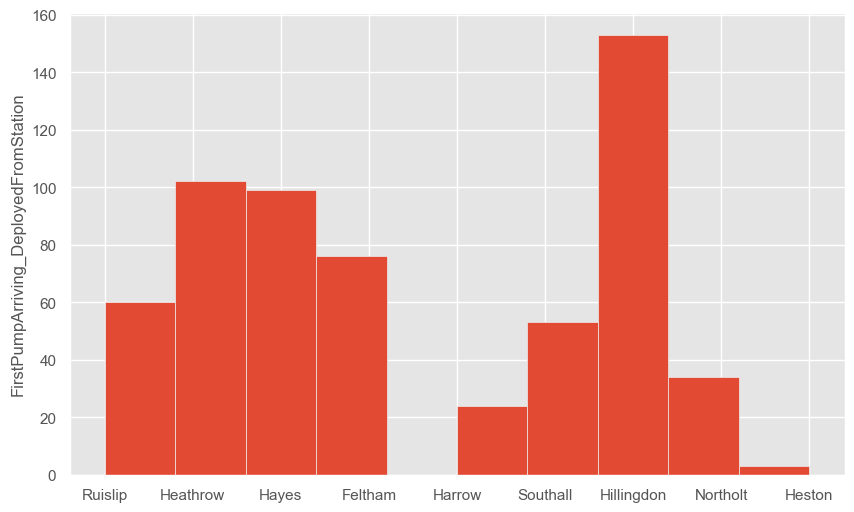

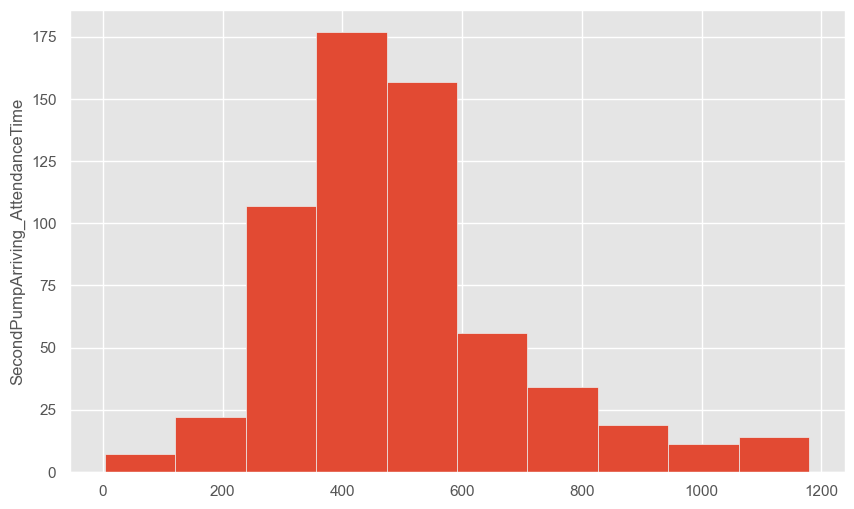

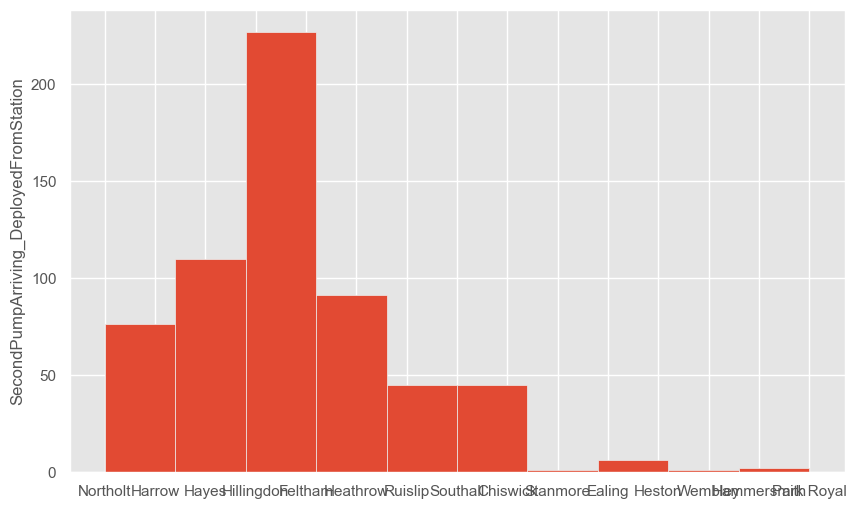

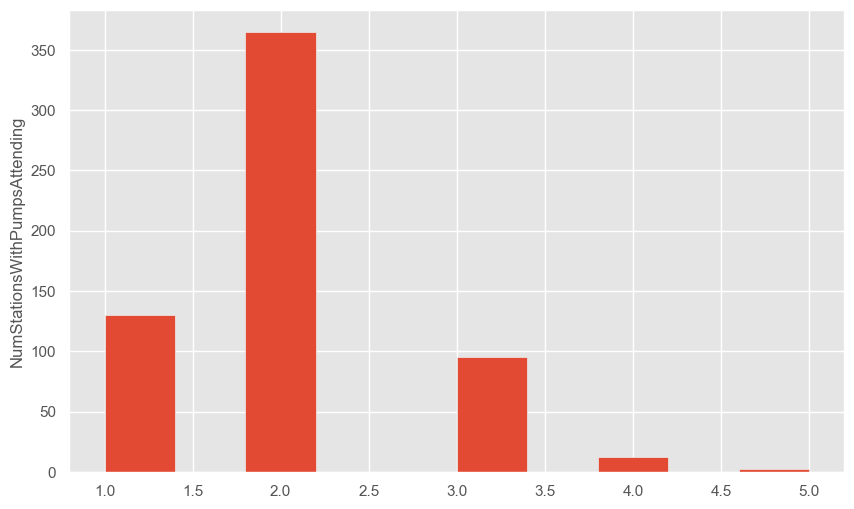

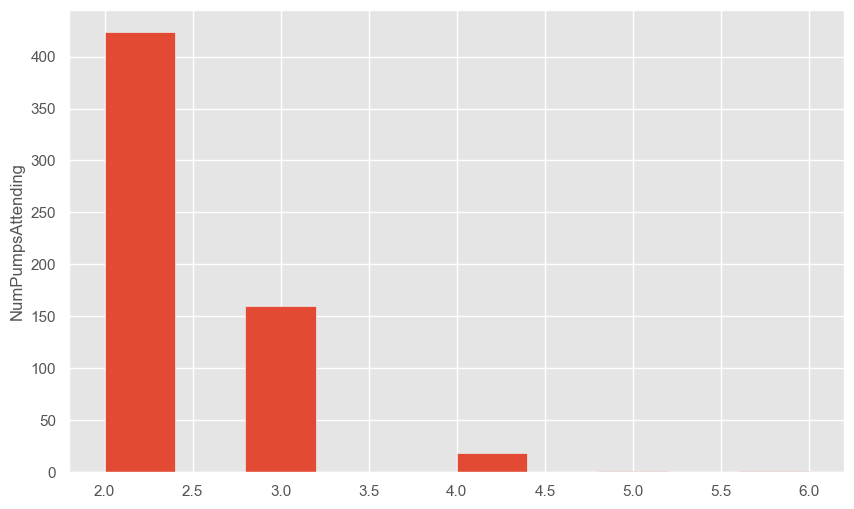

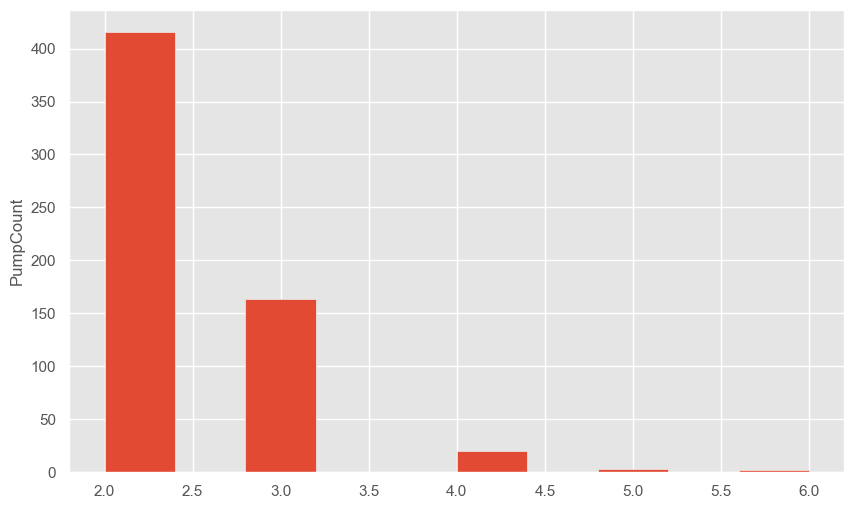

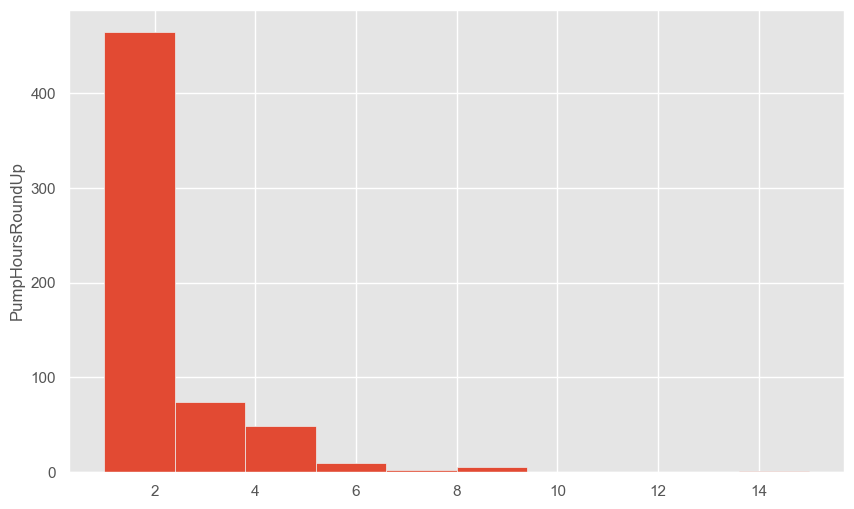

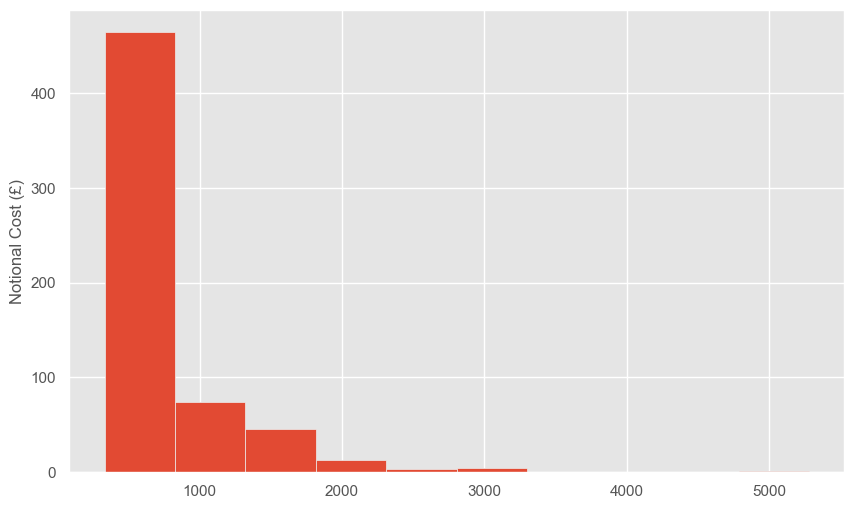

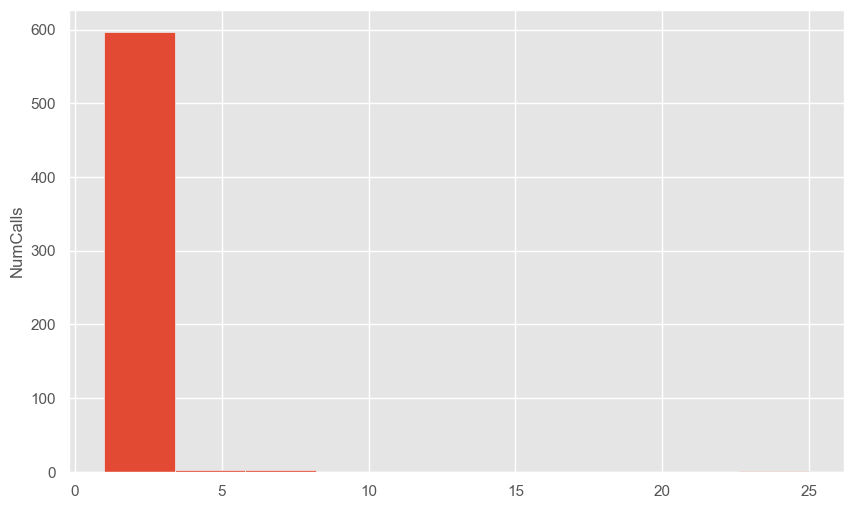

In [ ]:
for i in new_df[obj_li].columns:
    plt.figure(figsize=(10,6))
    plt.hist(new_df[obj_li][i])
    plt.ylabel(i)
    plt.show()

In [ ]:
new_df.head()

,level_0,index,IncidentNumber,DateOfCall,CalYear,TimeOfCall,HourOfCall,IncidentGroup,StopCodeDescription,SpecialServiceType,PropertyCategory,PropertyType,AddressQualifier,Postcode_full,Postcode_district,UPRN,USRN,IncGeo_BoroughCode,IncGeo_BoroughName,ProperCase,IncGeo_WardCode,IncGeo_WardName,IncGeo_WardNameNew,Easting_m,Northing_m,Easting_rounded,Northing_rounded,Latitude,Longitude,FRS,IncidentStationGround,FirstPumpArriving_AttendanceTime,FirstPumpArriving_DeployedFromStation,SecondPumpArriving_AttendanceTime,SecondPumpArriving_DeployedFromStation,NumStationsWithPumpsAttending,NumPumpsAttending,PumpCount,PumpHoursRoundUp,Notional Cost (£),NumCalls
0,0,758,001466-03012019,03 Jan 2019,2019,22:47:34,22,Special Service,Special Service,RTC,Road Vehicle,Multiple Vehicles,In street outside gazetteer location,HA6 1HF,HA6,100023661471,21401951,E09000017,HILLINGDON,Hillingdon,E05013574,Northwood,Northwood,509488.0,190806.0,509450,190850,51.605463,-0.420375,London,Ruislip,362.0,Ruislip,721.0,Northolt,2.0,2.0,5.0,3.0,999.0,2.0
1,1,1684,003039-07012019,07 Jan 2019,2019,20:21:50,20,Special Service,Special Service,RTC,Road Vehicle,Multiple Vehicles,In street outside gazetteer location,HA6 1NL,HA6,100023661139,21401058,E09000017,HILLINGDON,Hillingdon,E05013575,Northwood Hills,Northwood Hills,510212.0,189937.0,510250,189950,51.597515,-0.410185,London,Ruislip,425.0,Ruislip,551.0,Harrow,2.0,2.0,2.0,1.0,333.0,1.0
2,2,3048,005261-13012019,13 Jan 2019,2019,15:18:08,15,Special Service,Special Service,Other Transport incident,Aircraft,Passenger plane,In street outside gazetteer location,TW6 2AQ,TW6,768011491,21401419,E09000017,HILLINGDON,Hillingdon,E05013570,Heathrow Villages,Heathrow Villages,507702.0,176712.0,507750,176750,51.479132,-0.450452,London,Heathrow,132.0,Heathrow,303.0,Hayes,3.0,3.0,3.0,1.0,333.0,1.0
3,3,3529,005985-15012019,15 Jan 2019,2019,16:06:48,16,Special Service,Special Service,Suicide/attempts,Boat,Barge,Open land/water - nearest gazetteer location,UB7 8JR,UB7,10092980270,21401016,E09000017,HILLINGDON,Hillingdon,E05013584,Yiewsley,Yiewsley,506608.0,180080.0,506650,180050,51.509605,-0.465186,London,Hillingdon,368.0,Hayes,394.0,Hillingdon,2.0,2.0,2.0,2.0,666.0,1.0
4,4,3970,006720-17012019,17 Jan 2019,2019,10:06:37,10,Special Service,Special Service,Stand By,Aircraft,Passenger plane,On land associated with building,TW6 1DB,TW6,10090329613,21402329,E09000017,HILLINGDON,Hillingdon,E05013570,Heathrow Villages,Heathrow Villages,507533.0,175857.0,507550,175850,51.471479,-0.453153,London,Heathrow,334.0,Feltham,350.0,Feltham,2.0,3.0,3.0,2.0,666.0,1.0


# Outliers

KeyError: 'DateCall'

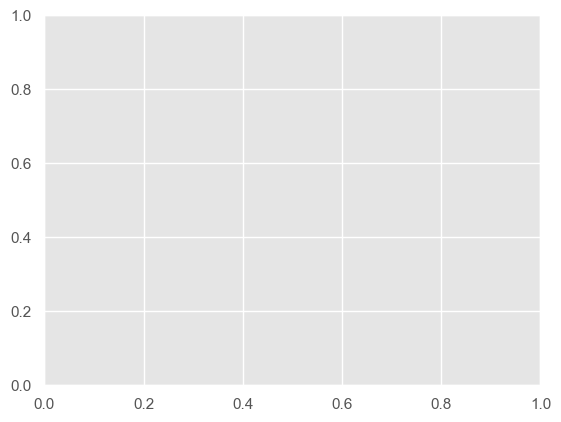

In [ ]:
# checking outliers
fig, ax = plt.subplots()
ax.scatter(x = new_df['HourOfCall'], y = new_df['DateOfCall'])
plt.ylabel('DateOfCall', fontsize=13)
plt.xlabel('HourOfCall', fontsize=13)
plt.show()

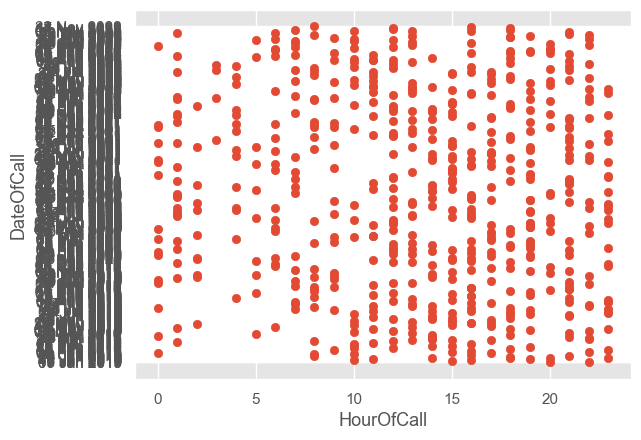

In [ ]:
#Deleting outliers
new_df= new_df.drop(new_df[(new_df['HourOfCall']>4000) & (new_df['UPRN']<300000)].index)

#Check the graphic again
fig, ax = plt.subplots()
ax.scatter(new_df['HourOfCall'], new_df['DateOfCall'])
plt.ylabel('DateOfCall', fontsize=13)
plt.xlabel('HourOfCall', fontsize=13)
plt.show()

In [ ]:
sns.distplot(new_df['UPRN'] , fit=norm);

# Get the fitted parameters used by the function
(mu, sigma) = norm.fit(new_df['UPRN'])
print( '\n mu = {:.2f} and sigma = {:.2f}\n'.format(mu, sigma))

#Now plot the distribution
plt.legend(['Normal dist. ($\mu=$ {:.2f} and $\sigma=$ {:.2f} )'.format(mu, sigma)],
            loc='best')
plt.ylabel('Frequency')
plt.title('UPRN distribution')

#Get also the QQ-plot
fig = plt.figure()
res = stats.probplot(new_df['UPRN'], plot=plt)
plt.show()

NameError: name 'norm' is not defined


 mu = 14.73 and sigma = 11.70



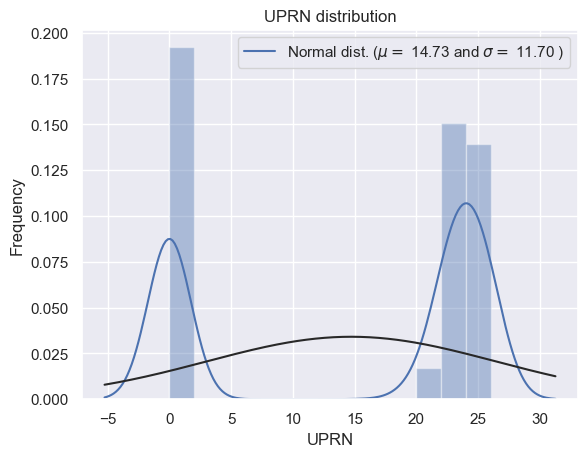

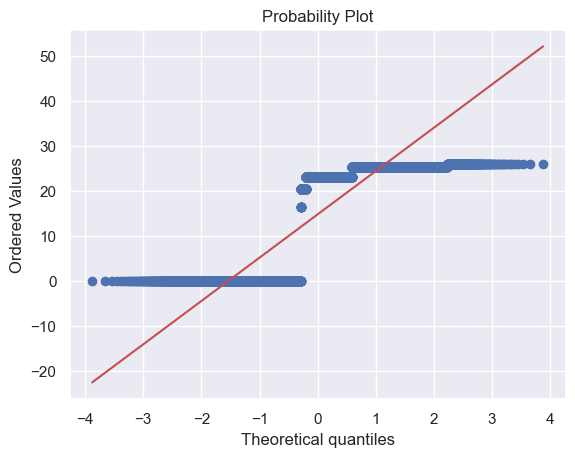

In [ ]:
#We use the numpy fuction log1p which  applies log(1+x) to all elements of the column
new_df["UPRN"] = np.log1p(new_df["UPRN"])

#Check the new distribution
sns.distplot(new_df['UPRN'] , fit=norm);

# Get the fitted parameters used by the function
(mu, sigma) = norm.fit(new_df['UPRN'])
print( '\n mu = {:.2f} and sigma = {:.2f}\n'.format(mu, sigma))

#Now plot the distribution
plt.legend(['Normal dist. ($\mu=$ {:.2f} and $\sigma=$ {:.2f} )'.format(mu, sigma)],
            loc='best')
plt.ylabel('Frequency')
plt.title('UPRN distribution')

#Get also the QQ-plot
fig = plt.figure()
res = stats.probplot(new_df['UPRN'], plot=plt)
plt.show()


# Feature scaling

# Feature encoding

# Data cleaning

In [ ]:
# Drop rows with missing values
new_df.dropna(inplace=True)

# Replace missing values with mean
new_df.fillna(new_df.mean(), inplace=True)

# Remove outliers
Q1 = new_df.quantile(0.25)
Q3 = new_df.quantile(0.75)
IQR = Q3 - Q1
new_df = new_df[~((new_df < (Q1 - 1.5 * IQR)) | (new_df > (Q3 + 1.5 * IQR))).any(axis=1)]
new_df


,level_0,index,IncidentNumber,DateOfCall,CalYear,TimeOfCall,HourOfCall,IncidentGroup,StopCodeDescription,SpecialServiceType,PropertyCategory,PropertyType,AddressQualifier,Postcode_full,Postcode_district,UPRN,USRN,IncGeo_BoroughCode,IncGeo_BoroughName,ProperCase,IncGeo_WardCode,IncGeo_WardName,IncGeo_WardNameNew,Easting_m,Northing_m,Easting_rounded,Northing_rounded,Latitude,Longitude,FRS,IncidentStationGround,FirstPumpArriving_AttendanceTime,FirstPumpArriving_DeployedFromStation,SecondPumpArriving_AttendanceTime,SecondPumpArriving_DeployedFromStation,NumStationsWithPumpsAttending,NumPumpsAttending,PumpCount,PumpHoursRoundUp,Notional Cost (£),NumCalls
1,1,1684,003039-07012019,07 Jan 2019,2019,20:21:50,20,Special Service,Special Service,RTC,Road Vehicle,Multiple Vehicles,In street outside gazetteer location,HA6 1NL,HA6,100023661139,21401058,E09000017,HILLINGDON,Hillingdon,E05013575,Northwood Hills,Northwood Hills,510212.0,189937.0,510250,189950,51.597515,-0.410185,London,Ruislip,425.0,Ruislip,551.0,Harrow,2.0,2.0,2.0,1.0,333.0,1.0
3,3,3529,005985-15012019,15 Jan 2019,2019,16:06:48,16,Special Service,Special Service,Suicide/attempts,Boat,Barge,Open land/water - nearest gazetteer location,UB7 8JR,UB7,10092980270,21401016,E09000017,HILLINGDON,Hillingdon,E05013584,Yiewsley,Yiewsley,506608.0,180080.0,506650,180050,51.509605,-0.465186,London,Hillingdon,368.0,Hayes,394.0,Hillingdon,2.0,2.0,2.0,2.0,666.0,1.0
4,4,3970,006720-17012019,17 Jan 2019,2019,10:06:37,10,Special Service,Special Service,Stand By,Aircraft,Passenger plane,On land associated with building,TW6 1DB,TW6,10090329613,21402329,E09000017,HILLINGDON,Hillingdon,E05013570,Heathrow Villages,Heathrow Villages,507533.0,175857.0,507550,175850,51.471479,-0.453153,London,Heathrow,334.0,Feltham,350.0,Feltham,2.0,3.0,3.0,2.0,666.0,1.0
6,6,4378,007352-18012019,18 Jan 2019,2019,19:01:10,19,Special Service,Special Service,RTC,Road Vehicle,Car,In street outside gazetteer location,UB3 5DD,UB3,10025573362,21402608,E09000017,HILLINGDON,Hillingdon,E05013570,Heathrow Villages,Heathrow Villages,508693.0,177656.0,508650,177650,51.487420,-0.435897,London,Hayes,298.0,Hayes,302.0,Heathrow,2.0,2.0,2.0,1.0,333.0,1.0
7,7,4643,007798-19012019,19 Jan 2019,2019,18:42:53,18,Special Service,Special Service,RTC,Road Vehicle,Car,In street outside gazetteer location,HA5 1QH,HA5,10025568821,21400732,E09000017,HILLINGDON,Hillingdon,E05013567,Eastcote,Eastcote,511004.0,187900.0,511050,187950,51.579052,-0.399409,London,Ruislip,267.0,Harrow,406.0,Ruislip,2.0,2.0,2.0,1.0,333.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
598,598,418508,182937-06112022,06 Nov 2022,2022,18:21:00,18,Special Service,Special Service,RTC,Road Vehicle,Car,On land associated with building,UB8 2TX,UB8,100021489695,21401376,E09000017,HILLINGDON,Hillingdon,E05013580,UXBRIDGE,UXBRIDGE,505264.0,183968.0,505250,183950,51.544807,-0.483385,London,Hillingdon,326.0,Hillingdon,572.0,Ruislip,2.0,2.0,2.0,1.0,364.0,1.0
599,599,418715,183252-07112022,07 Nov 2022,2022,12:32:58,12,Special Service,Special Service,No action (not false alarm),Road Vehicle,Car,In street close to gazetteer location,UB8 1NT,UB8,10022803234,21402130,E09000017,HILLINGDON,Hillingdon,E05013580,UXBRIDGE,UXBRIDGE,506203.0,185584.0,506250,185550,51.559159,-0.469368,London,Hillingdon,571.0,Ruislip,638.0,Hillingdon,2.0,2.0,2.0,1.0,364.0,1.0
600,600,420062,185425-11112022,11 Nov 2022,2022,12:31:21,12,Special Service,Special Service,RTC,Road Vehicle,Multiple Vehicles,In street outside gazetteer location,UB10 8HF,UB10,100021475821,21400234,E09000017,HILLINGDON,Hillingdon,E05013573,ICKENHAM & SOUTH HAREFIELD,ICKENHAM & SOUTH HAREFIELD,507043.0,186923.0,507050,186950,51.571031,-0.456838,London,Ruislip,402.0,Hillingdon,416.0,Ruislip,2.0,2.0,2.0,2.0,728.0,1.0
601,601,421921,188365-16112022,16 Nov 2022,2022,18:31:46,18,Special Service,Special Service,RTC,Road Vehicle,Mult

In [ ]:
# Check the percentage of Nan in dataset
total = new_df.isnull().sum().sort_values(ascending=False)
total

level_0                                   0
IncGeo_WardName                           0
Easting_m                                 0
Northing_m                                0
Easting_rounded                           0
Northing_rounded                          0
Latitude                                  0
Longitude                                 0
FRS                                       0
IncidentStationGround                     0
FirstPumpArriving_AttendanceTime          0
FirstPumpArriving_DeployedFromStation     0
SecondPumpArriving_AttendanceTime         0
SecondPumpArriving_DeployedFromStation    0
NumStationsWithPumpsAttending             0
NumPumpsAttending                         0
PumpCount                                 0
PumpHoursRoundUp                          0
Notional Cost (£)                         0
IncGeo_WardNameNew                        0
IncGeo_WardCode                           0
index                                     0
ProperCase                      

# Data Correlation

<AxesSubplot:>

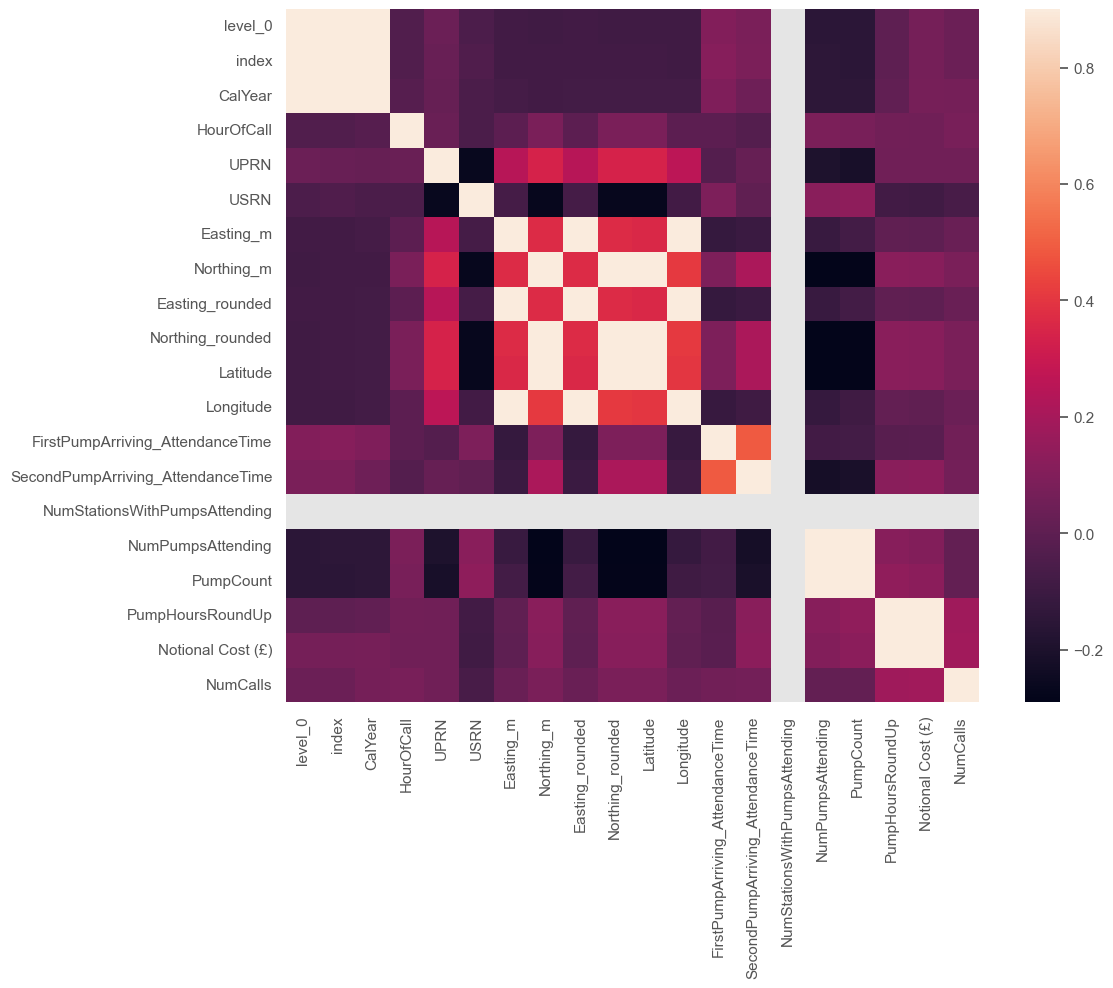

In [ ]:
#Correlation map to see how features are correlated with UPRN
corrmat = new_df.corr()
plt.subplots(figsize=(12,9))
sns.heatmap(corrmat, vmax=0.9, square=True)

# Visualization of Data

<AxesSubplot:>

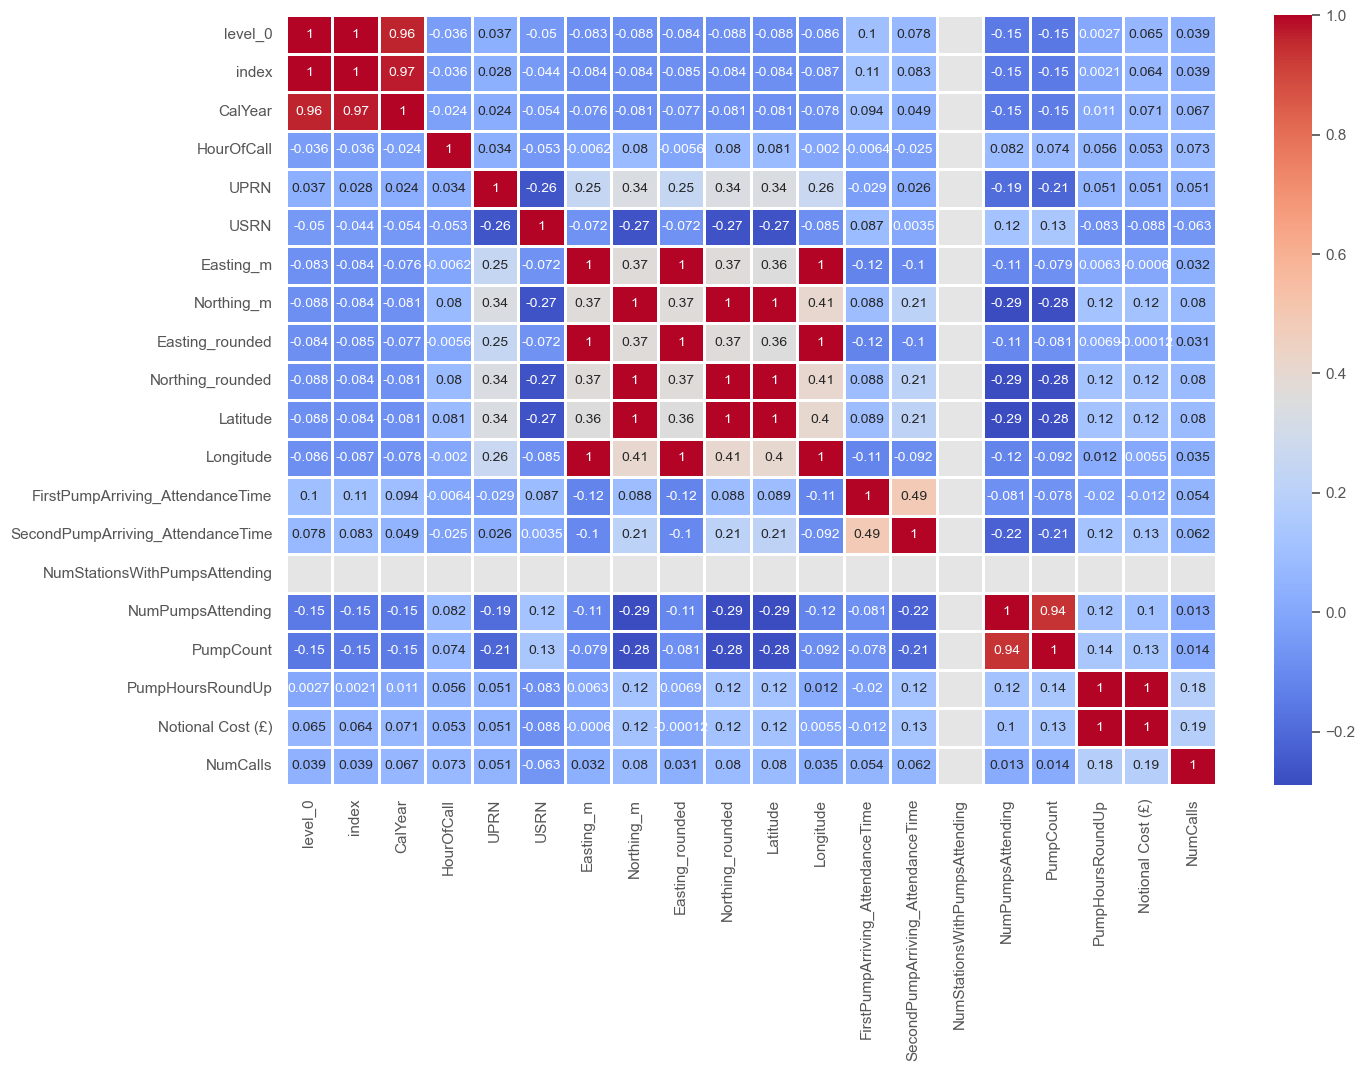

In [ ]:
fig, ax = plt.subplots()
fig.set_size_inches(15, 10)
sns.heatmap(new_df.corr(),cmap='coolwarm',ax=ax,annot=True,linewidths=2)

# data partitioning